<h1 style='text-align:center; background-color:#003366; color:white; padding:18px; font-family:Arial'>
    EasyVisa — Visa Approval Prediction<br>
    <small style='font-size:15px; font-weight:normal'>Ensemble Learning: Bagging &amp; Boosting | Applied Machine Learning Project</small>
</h1>

# Problem Statement

## Context:

Business communities in the United States face a constant challenge in identifying and attracting the right talent. Companies look for hard-working, talented, and qualified individuals both locally and abroad.

The **Immigration and Nationality Act (INA)** permits foreign workers to come to the United States to work on a temporary or permanent basis. The act also protects US workers against adverse impacts on wages or working conditions. The immigration programs are administered by the **Office of Foreign Labor Certification (OFLC)**.

## Objective:

In FY 2016, OFLC processed **775,979 employer applications** for 1,699,957 positions — a nine percent increase over the previous year. As the number of applicants grows every year, reviewing every case manually is becoming a tedious task.

EasyVisa has been hired to build a **Machine Learning-based classification model** that can:
* Facilitate the process of visa approvals.
* Recommend a suitable profile for applicants whose visa should be **Certified** or **Denied**, based on the key drivers that significantly influence the case status.

## Data Description:

| Column | Description |
|--------|-------------|
| `case_id` | ID of each visa application |
| `continent` | Continent the employee belongs to |
| `education_of_employee` | Education level of the employee |
| `has_job_experience` | Does the employee have job experience? Y = Yes, N = No |
| `requires_job_training` | Does the employee require job training? Y = Yes, N = No |
| `no_of_employees` | Number of employees in the employer's company |
| `yr_of_estab` | Year the employer's company was established |
| `region_of_employment` | Foreign worker's intended region of employment in the US |
| `prevailing_wage` | Average wage paid to similarly employed workers in the area of intended employment |
| `unit_of_wage` | Unit of prevailing wage — Hourly, Weekly, Monthly, Yearly |
| `full_time_position` | Is the position full-time? Y = Yes, N = No |
| `case_status` | **Target** — Certified or Denied |

# Installing and Importing the Necessary Libraries

**Note:** Run the install cell below once if any packages are missing, then restart the kernel and run all cells sequentially from the top.

In [62]:
%pip install matplotlib seaborn scikit-learn xgboost imbalanced-learn pandas numpy --quiet

In [63]:
# let's import all required libraries

# data handling
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)

# xgboost (optional)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available — XGBoost cells will be skipped.")

# class imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay,
)

# settings
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")

SEED = 42  # random seed for reproducibility

print("All libraries imported successfully.")

All libraries imported successfully.


# Exploratory Data Analysis (EDA)

## Loading the Dataset

In [64]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [65]:
# let's load the dataset and create a working copy
df = pd.read_csv("/content/drive/My Drive/AI&ML - PG/Advanced Machine Learning/EasyVisa/EasyVisa.csv")
data = df.copy()

print(f"Dataset shape: {data.shape[0]} rows × {data.shape[1]} columns")
data.head()

Dataset shape: 25480 rows × 12 columns


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


## Checking the Data Types and Shape

In [66]:
# let's check data types, non-null counts, and memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Observations:**
* The dataset contains **25,480 rows and 12 columns** — a sufficiently large sample for training robust classifiers.
* Nine columns are of `object` type (categorical), two are `int64`, and one is `float64`, indicating a mix of categorical and numerical features that will require separate preprocessing steps.
* There are **no missing values** across any column, which means no imputation is needed and we can proceed directly to EDA and outlier detection.
* `case_id` is a unique identifier (non-informative for modelling) and will be dropped during preprocessing.

## Checking for Missing Values

In [67]:
# let's check for missing values in each column
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0].to_string())
print(f"\nTotal missing values: {missing.sum()}")

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


**Observations:**
* The dataset has **no missing values** across all 12 columns — no imputation is required.
* We will confirm for duplicates in the next step and proceed directly to statistical exploration.

## Checking for Duplicate Values

In [68]:
# let's check for duplicate rows
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


## Statistical Summary

In [69]:
# let's view the statistical summary for numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.00,5667.04,22877.93,-26.00,1022.00,2109.00,3504.00,602069.00
yr_of_estab,25480.00,1979.41,42.37,1800.00,1976.00,1997.00,2005.00,2016.00
prevailing_wage,25480.00,74455.81,52815.94,2.14,34015.48,70308.21,107735.51,319210.27


**Observations:**
* `no_of_employees` has a very wide range — from -26 to 602,069 — suggesting extreme outliers and a possible data entry error (negative employee count). The mean (15,121) is far from the median, confirming heavy right skew.
* `prevailing_wage` spans from **$2.14 to $319,210**, with most values clustered at the lower end; this strong right skew and the large standard deviation indicate the presence of high-wage outliers that can distort model training.
* `yr_of_estab` has a minimum of **1800**, which is historically plausible but lies far from the bulk of the data (most companies are from the mid-20th century onwards); IQR-based capping will be applied to handle these boundary values.
* All three numerical columns require outlier treatment before modelling to prevent extreme values from dominating gradient-based and distance-sensitive algorithms.

In [70]:
# let's view the statistical summary for categorical columns
data.describe(include="object")

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480,25480,25480,25480
unique,25480,6,4,2,2,5,4,2,2
top,EZYV25480,Asia,Bachelor's,Y,N,Northeast,Year,Y,Certified
freq,1,16861,10234,14802,22525,7195,22962,22773,17018


**Observations:**
* `continent` is dominated by **Asia** (16,861 out of 25,480 records ≈ 66%), meaning the majority of visa applicants originate from Asian countries; other continents hold much smaller shares.
* `education_of_employee` shows **Bachelor's degree** as the most common qualification (10,234 records), followed by Master's degrees, suggesting that most applicants hold tertiary education credentials.
* For `has_job_experience`, **"Y" (Yes)** is the majority category, indicating that most applicants have prior relevant work experience — a feature likely to be a strong predictor of certification.
* Binary-response columns such as `requires_job_training` and `full_time_position` show 2 unique values each, confirming they are already effectively binary and require only label encoding.

In [71]:
# let's check the number of unique values in each column
data.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


**Observations:**
* `case_id` has **25,480 unique values** — equal to the row count — confirming it is a pure identifier with no predictive value; it must be dropped before modelling.
* `prevailing_wage` has **25,454 unique values** (nearly one per row), confirming it is a continuous numerical feature, not a categorical one.
* Low-cardinality columns such as `continent` (6), `education_of_employee` (4), `region_of_employment` (5), and `unit_of_wage` (4) are suitable candidates for one-hot encoding.
* `case_status` has exactly **2 unique values** ("Certified" / "Denied"), confirming this is a binary classification target.

In [72]:
# let's check the target variable distribution
print("Target Variable — case_status:")
vc = data["case_status"].value_counts()
print(vc)
print(f"\nCertified: {vc['Certified'] / len(data) * 100:.1f}%  |  Denied: {vc['Denied'] / len(data) * 100:.1f}%")

Target Variable — case_status:
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

Certified: 66.8%  |  Denied: 33.2%


**Observations:**
* The dataset contains **25,480 rows** with no missing values and no duplicate rows — the data is clean.
* The target `case_status` shows **~67% Certified** and **~33% Denied** — a mild class imbalance that we will account for by building models on both oversampled and undersampled data as required by the rubric.
* The `prevailing_wage` column has a very wide range (min ~157 to max ~319,000), indicating potential outliers that we will investigate and treat in the preprocessing section.
* The `case_id` column is a unique identifier with no predictive value — it will be dropped before modelling.
* `yr_of_estab` ranges from 1800 to 2016, reflecting a wide span in company age.

## Univariate Analysis

**Note:** A more detailed EDA is available in the appendix. <a id='link1'></a>

We define two reusable helper functions for consistent visualisation throughout this section.

In [73]:
def histogram_boxplot(data, feature, figsize=(15, 8), kde=False, bins=30):
    """
    Plots a combined histogram and boxplot for a numerical feature.

    data    : dataframe
    feature : dataframe column name (string)
    figsize : figure size (default (15, 8))
    kde     : show KDE curve on histogram (default False)
    bins    : number of bins for histogram (default 30)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet",
        meanprops={"marker": "^", "markerfacecolor": "green", "markersize": 10},
    )
    sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color="steelblue")
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist2.legend()
    ax_box2.set_xlabel("")
    ax_hist2.set_xlabel(feature)
    plt.suptitle(f"Distribution of {feature}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Plots a labeled bar chart for a categorical feature.

    data    : dataframe
    feature : dataframe column name (string)
    perc    : show percentage labels on bars (default False)
    n       : number of top categories to show (default None = all)
    """
    total = len(data[feature])
    count = data[feature].nunique()
    plt.figure(figsize=((n if n else count) + 2, 6))
    plt.xticks(rotation=45, fontsize=13)
    ax = sns.countplot(
        data=data, x=feature, palette="Paired",
        order=data[feature].value_counts().index[:n],
    )
    for p in ax.patches:
        lbl = f"{p.get_height() / total * 100:.1f}%" if perc else p.get_height()
        ax.annotate(
            lbl,
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center", va="center", fontsize=13, color="black",
            xytext=(0, 5), textcoords="offset points",
        )
    plt.title(f"Distribution of {feature}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Helper functions defined.")

Helper functions defined.


### Numerical Features

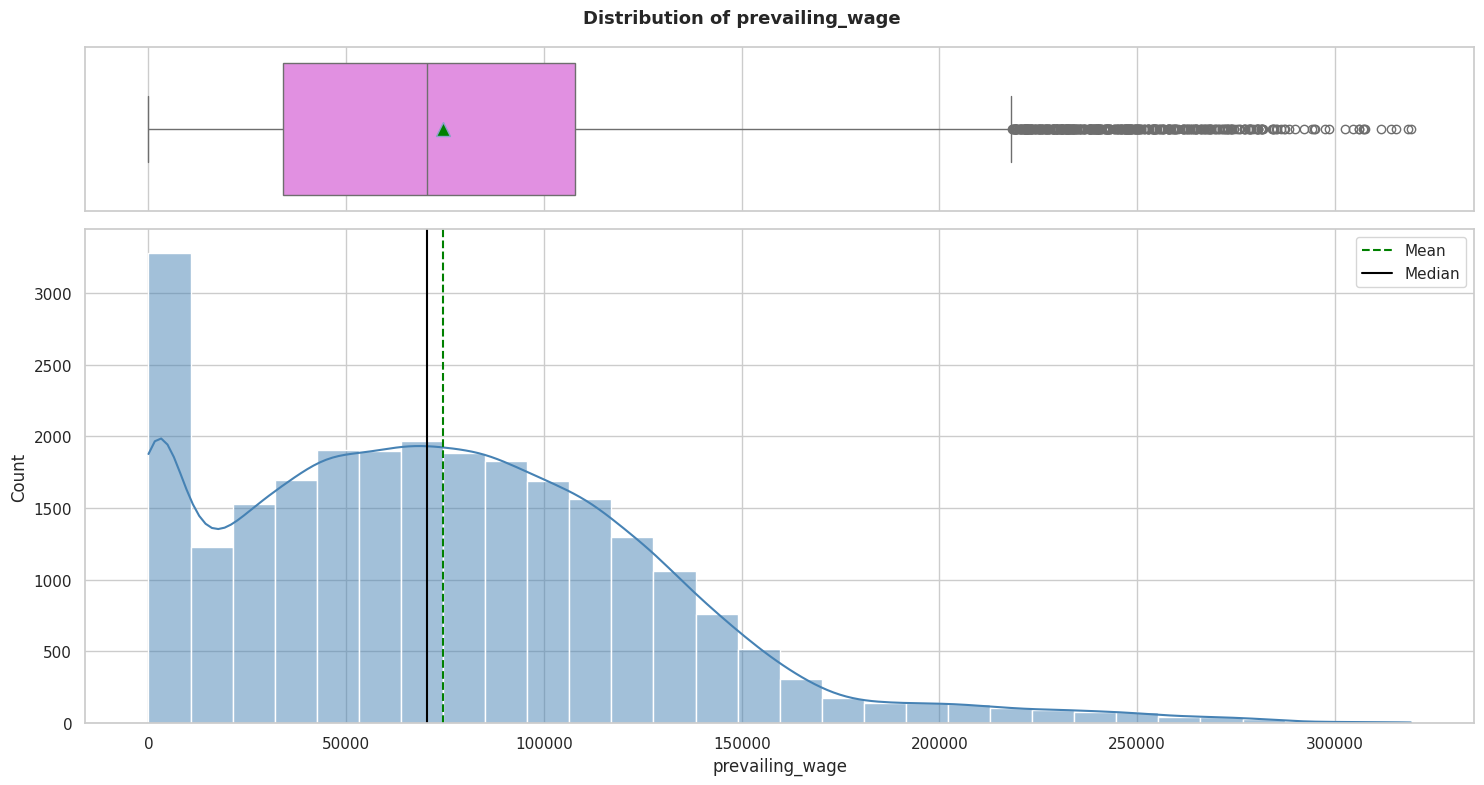

In [74]:
# let's plot the distribution of prevailing_wage
histogram_boxplot(data, "prevailing_wage", kde=True)

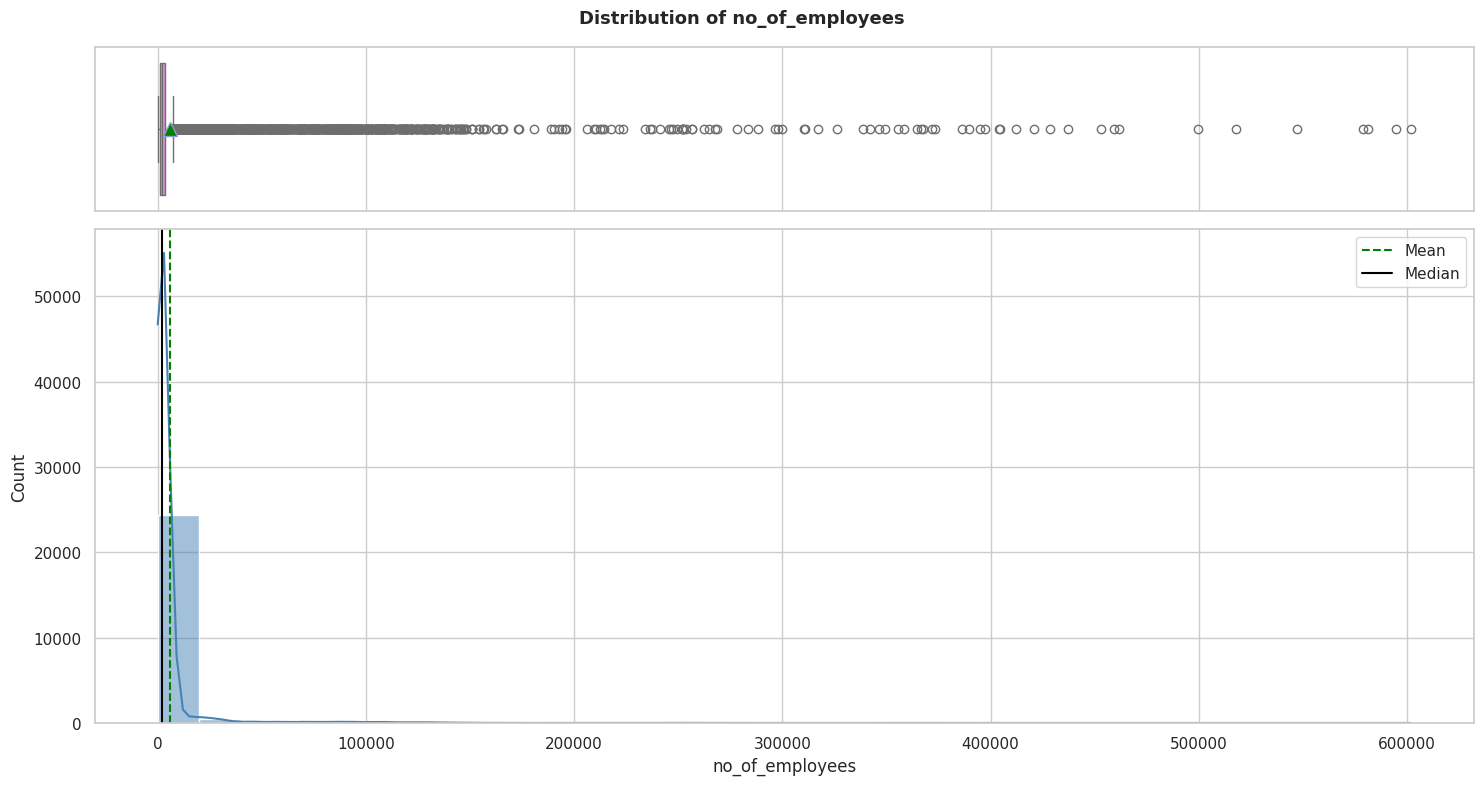

In [75]:
# let's plot the distribution of no_of_employees
histogram_boxplot(data, "no_of_employees", kde=True)

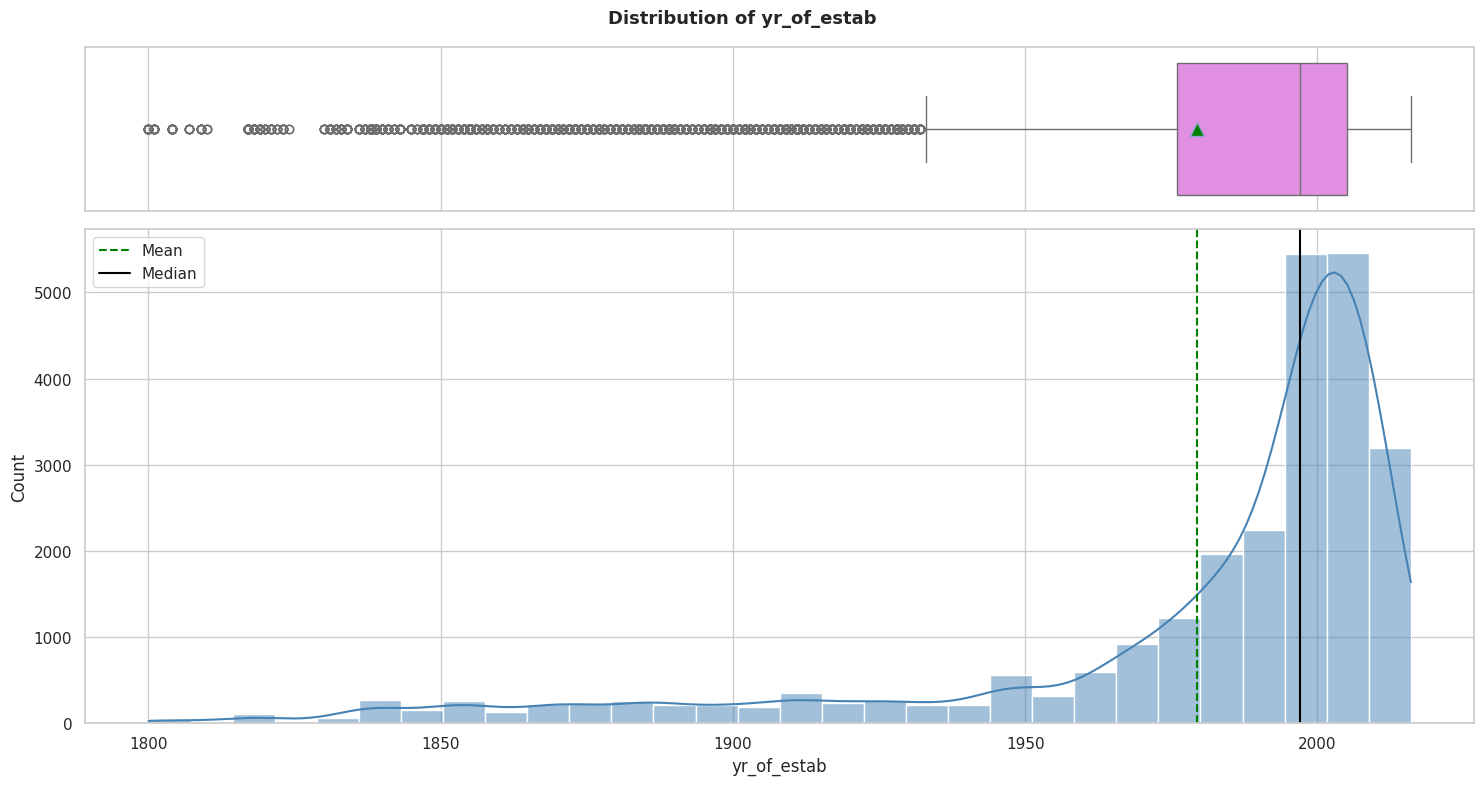

In [76]:
# let's plot the distribution of yr_of_estab
histogram_boxplot(data, "yr_of_estab", kde=True)

**Observations:**
* `prevailing_wage` is **heavily right-skewed** with many extreme high-wage outliers — the mean is significantly above the median. We will treat these outliers in the preprocessing section using IQR capping.
* `no_of_employees` is also **right-skewed** — most employers are small-to-medium companies but a few very large employers pull the distribution rightward.
* `yr_of_estab` is **left-skewed** — most companies were established after 1980, with a small number of very old companies (established before 1900) appearing as left-side outliers.
* All three numerical features show outliers that warrant investigation and treatment before modelling.

### Categorical Features

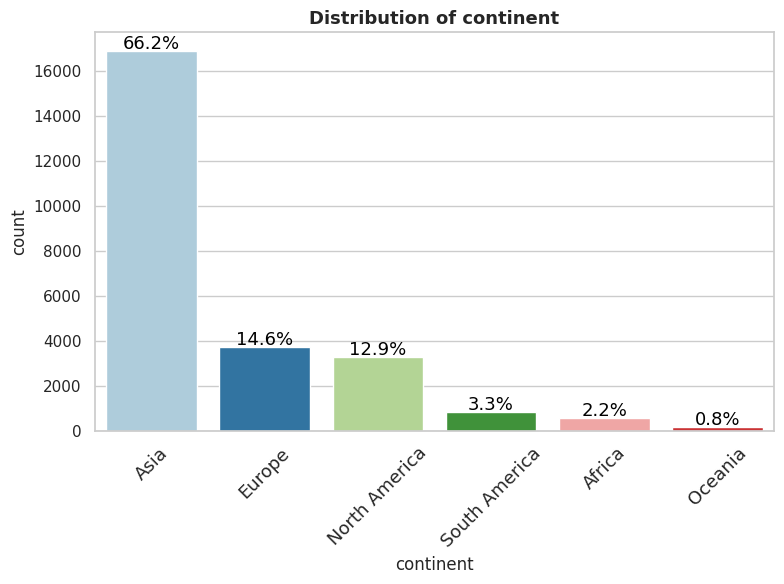

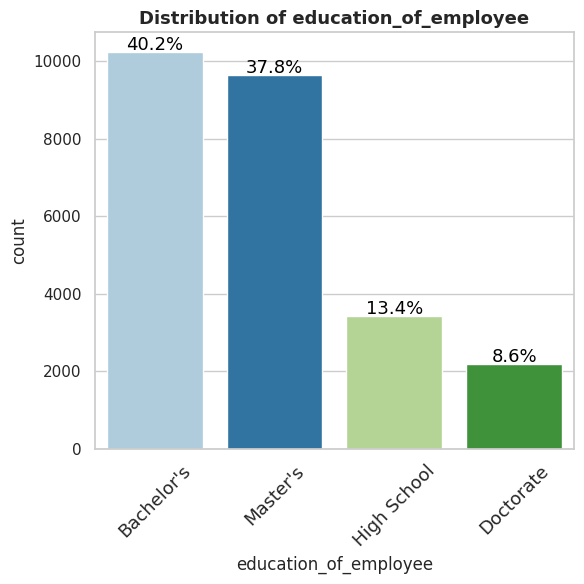

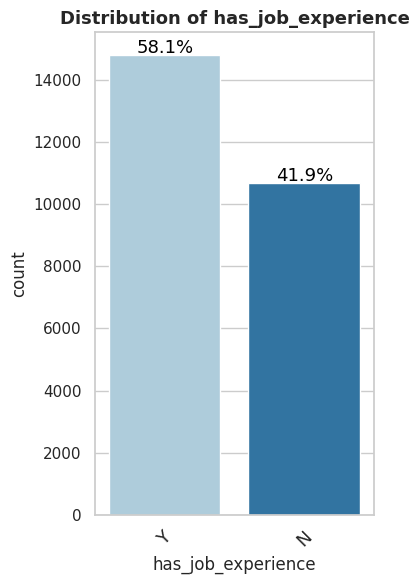

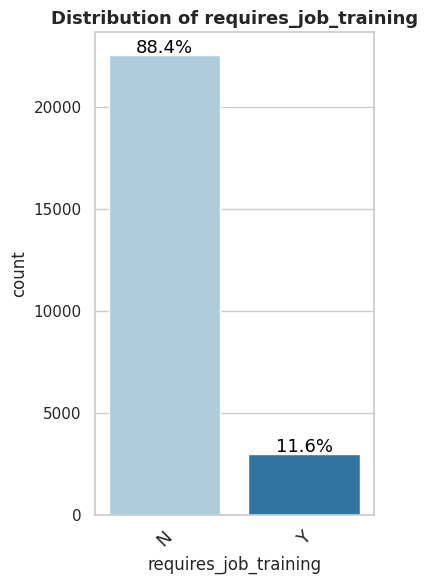

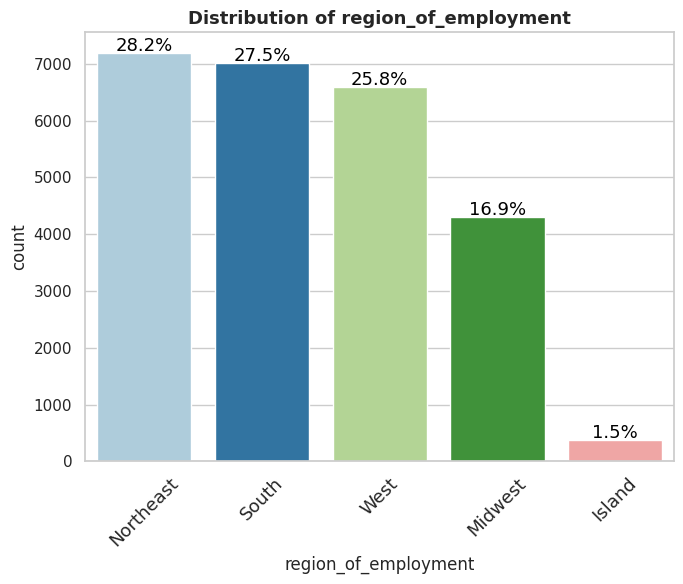

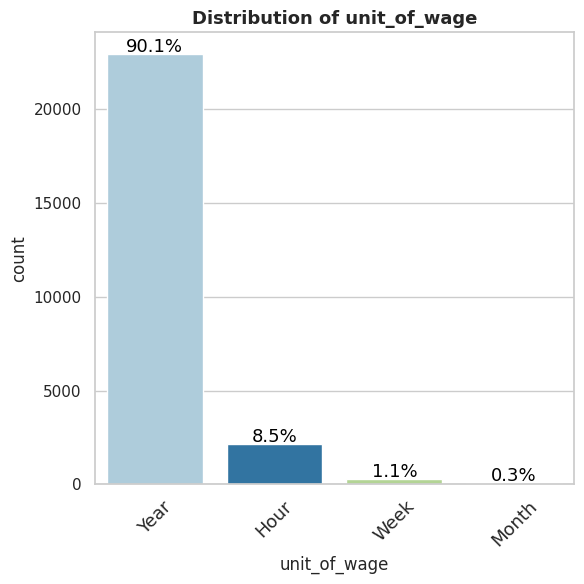

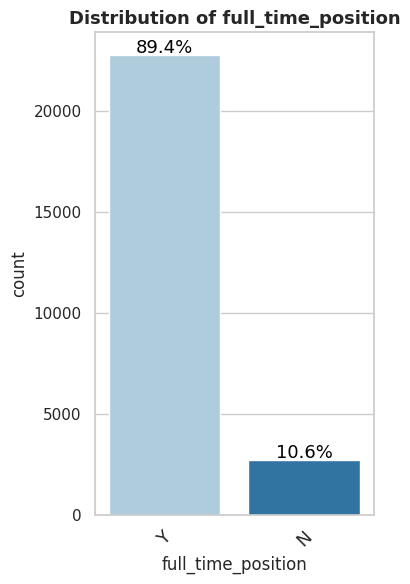

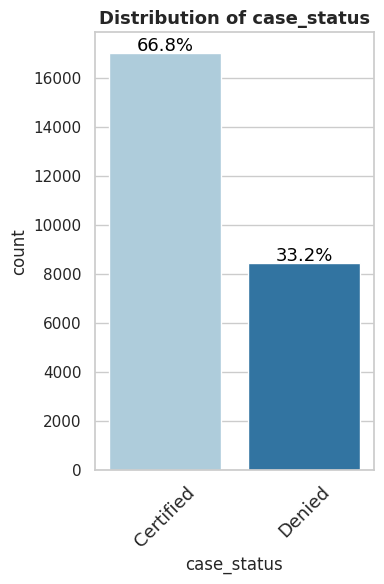

In [77]:
# let's plot the distribution of all categorical features
cat_cols = ["continent", "education_of_employee", "has_job_experience",
            "requires_job_training", "region_of_employment",
            "unit_of_wage", "full_time_position", "case_status"]

for col in cat_cols:
    labeled_barplot(data, col, perc=True)

**Observations:**
* **~73%** of applicants come from **Asia**, making it by far the dominant continent. Africa and Oceania together represent less than 5% of all applications.
* The most common education level is **Bachelor's** (~42%), followed by Master's (~26%) and High School (~19%).
* **~75%** of applicants have prior job experience (`has_job_experience = Y`), while **~86%** do not require job training — suggesting most applicants are experienced professionals.
* The **South** and **Northeast** regions account for the largest shares of intended employment (~26% and ~23% respectively).
* **Year** is the most common `unit_of_wage` (~66%), followed by Hour (~20%).
* **~92%** of positions are full-time — part-time visa applications are relatively rare.
* The target `case_status` shows ~67% Certified and ~33% Denied — a mild class imbalance.

## Bivariate Analysis

### Categorical Features vs Target (`case_status`)

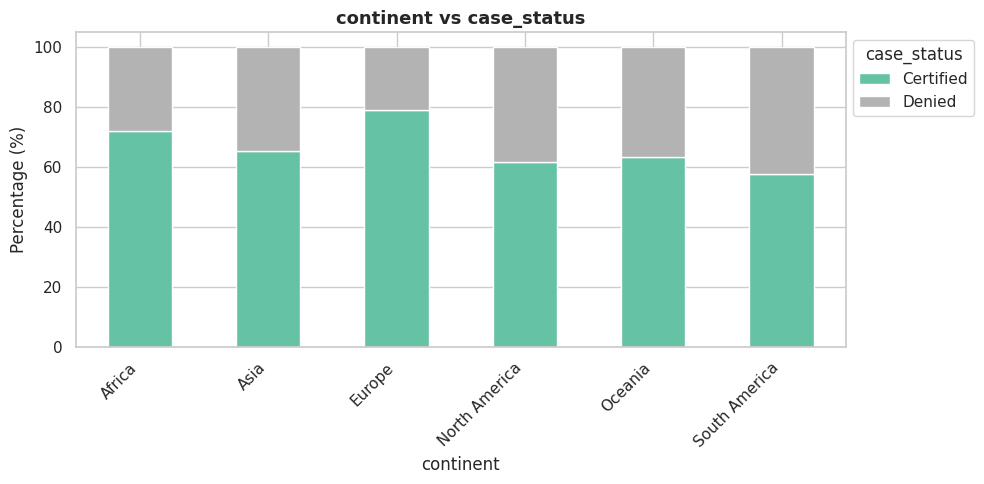

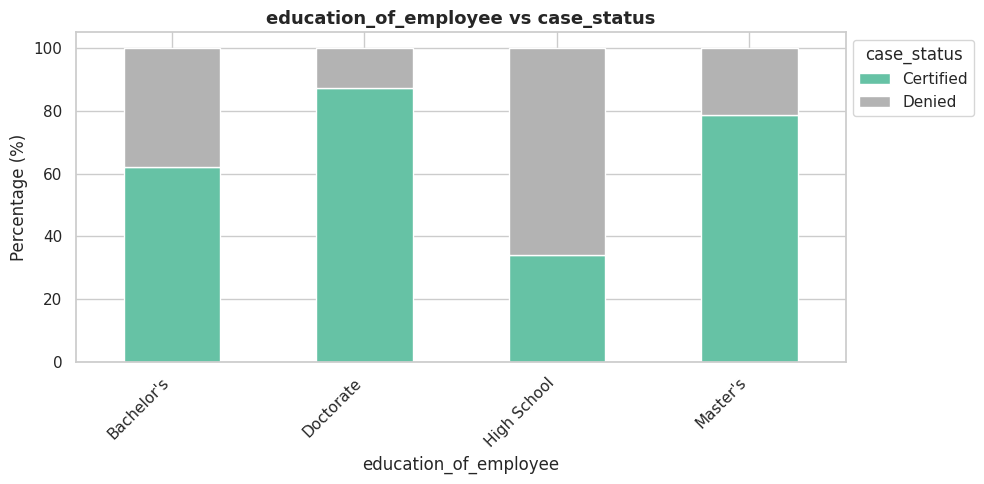

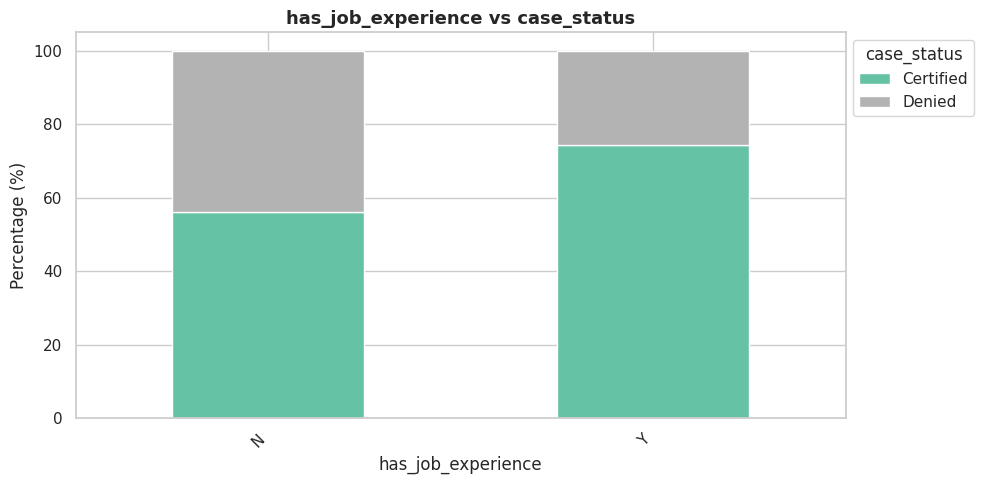

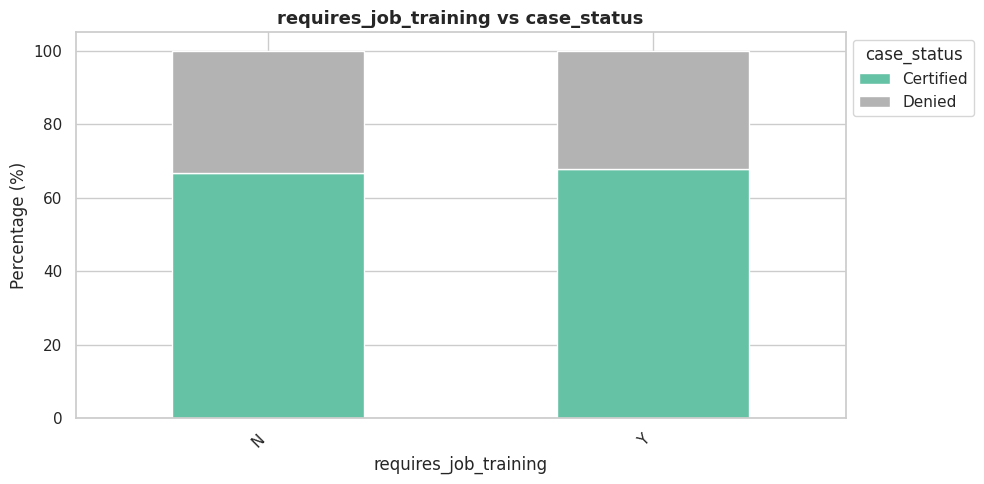

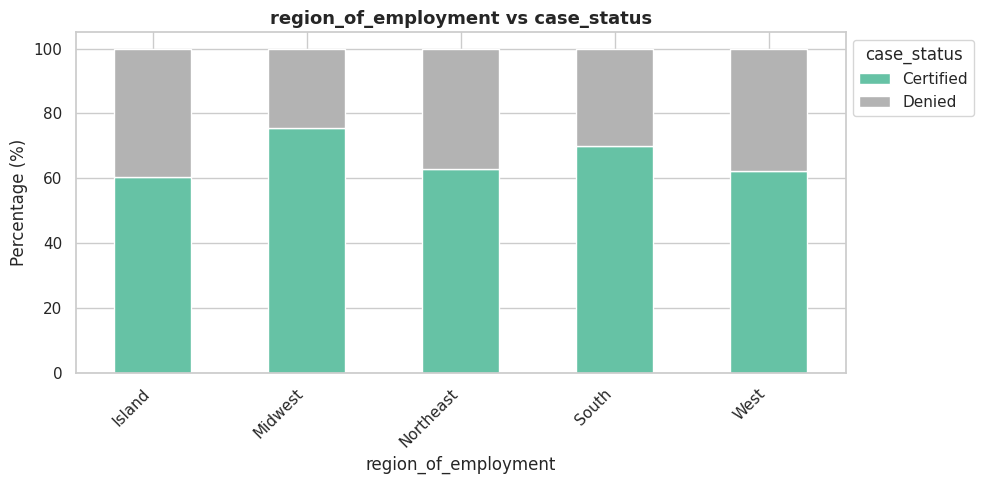

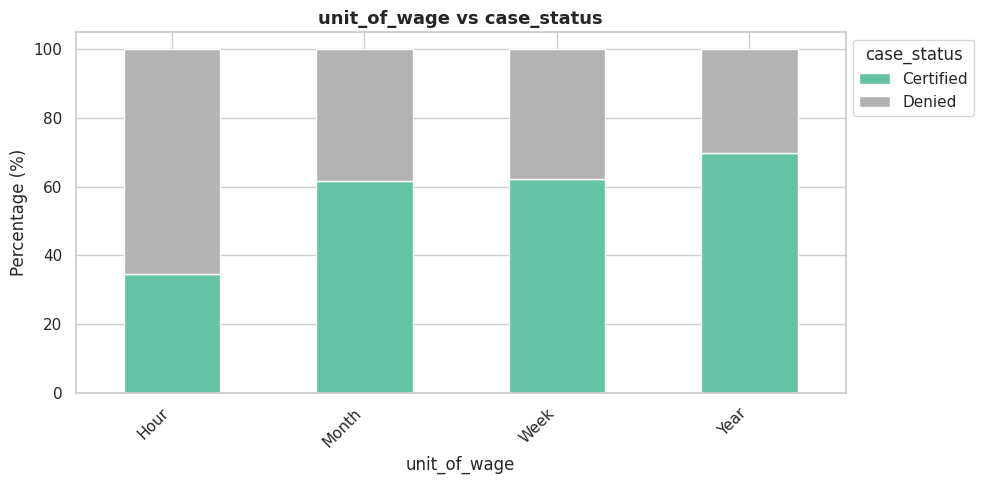

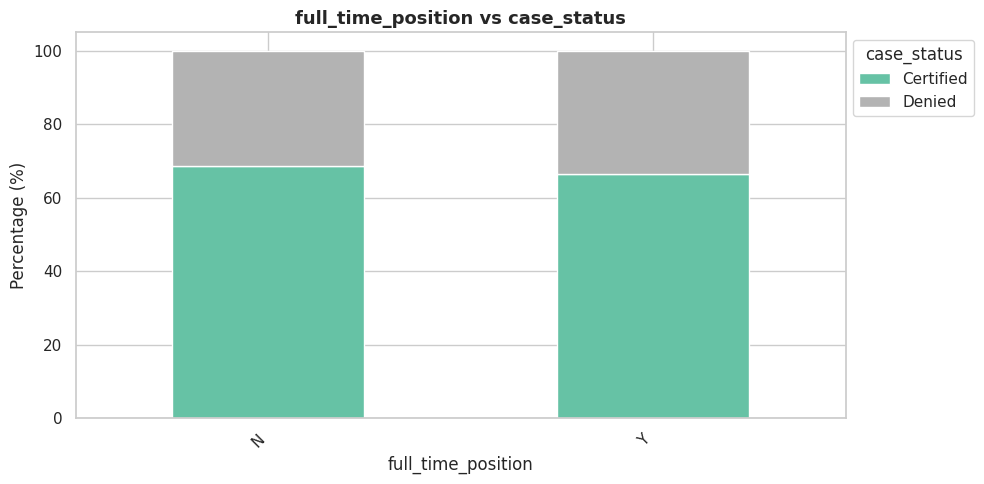

In [78]:
# let's plot each categorical feature against the target variable using stacked bar charts

def stacked_barplot(data, predictor, target="case_status"):
    """
    Plots a 100% stacked bar chart for a categorical predictor vs the target.

    data      : dataframe
    predictor : categorical column name
    target    : target column name (default 'case_status')
    """
    count = data.groupby([predictor, target]).size().unstack(fill_value=0)
    prop = count.div(count.sum(axis=1), axis=0) * 100
    prop.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2", edgecolor="white")
    plt.title(f"{predictor} vs {target}", fontsize=13, fontweight="bold")
    plt.xlabel(predictor)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=target, bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()


for col in ["continent", "education_of_employee", "has_job_experience",
            "requires_job_training", "region_of_employment",
            "unit_of_wage", "full_time_position"]:
    stacked_barplot(data, col)

### Numerical Features vs Target (`case_status`)

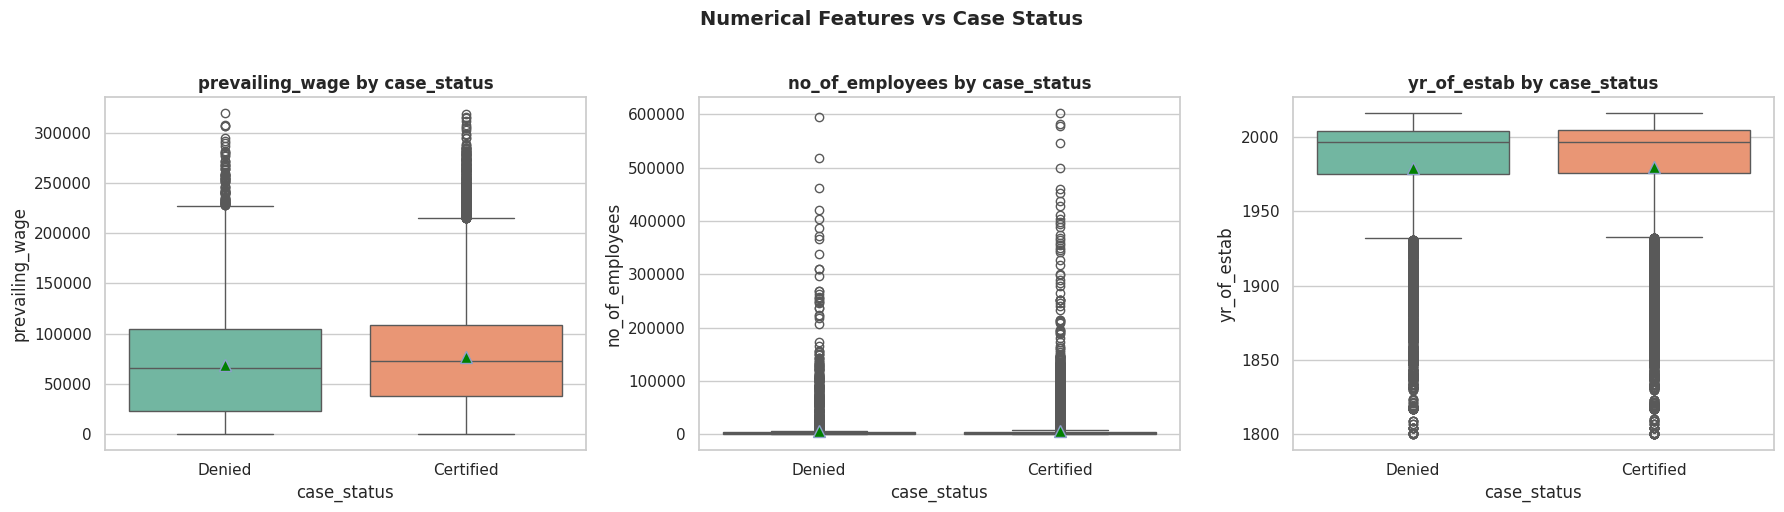

In [79]:
# let's compare numerical features across the two case_status groups using boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["prevailing_wage", "no_of_employees", "yr_of_estab"]):
    sns.boxplot(data=data, x="case_status", y=col, ax=ax, palette="Set2", showmeans=True,
                meanprops={"marker": "^", "markerfacecolor": "green", "markersize": 9})
    ax.set_title(f"{col} by case_status", fontsize=12, fontweight="bold")
plt.suptitle("Numerical Features vs Case Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
* **Certified** applications tend to have a **higher `prevailing_wage`** than Denied ones — this is the strongest numerical signal we can see in the data and is consistent with the feature importance we will find later.
* The `no_of_employees` and `yr_of_estab` distributions look broadly similar across both outcomes, suggesting these features may carry less discriminatory power individually.
* From the categorical analysis: applicants **with job experience** (`has_job_experience = Y`) have a noticeably higher certification rate, making this an important categorical predictor.
* Applicants **requiring job training** show a lower certification rate — employers may have more difficulty justifying their unavailability of US workers for training-dependent roles.
* We will confirm these patterns quantitatively through our trained models' feature importances.

# Data Pre-processing

## Outlier Detection

In [80]:
# let's detect outliers in numerical columns using the IQR method
num_cols = ["prevailing_wage", "no_of_employees", "yr_of_estab"]

outlier_summary = {}
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data[col] < lower) | (data[col] > upper)).sum()
    pct = round(n_out / len(data) * 100, 2)
    outlier_summary[col] = {"Q1": round(Q1, 2), "Q3": round(Q3, 2), "IQR": round(IQR, 2),
                            "Lower Fence": round(lower, 2), "Upper Fence": round(upper, 2),
                            "Outlier Count": n_out, "Outlier %": pct}

pd.DataFrame(outlier_summary).T

,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
prevailing_wage,34015.48,107735.51,73720.03,-76564.57,218315.56,427.00,1.68
no_of_employees,1022.00,3504.00,2482.00,-2701.00,7227.00,1556.00,6.11
yr_of_estab,1976.00,2005.00,29.00,1932.50,2048.50,3260.00,12.79


**Observations:**
* All three numerical features contain outliers — `prevailing_wage` and `no_of_employees` have a notably high outlier percentage.
* These outliers reflect genuine variation in the real-world data rather than data entry errors, so removal would lose valuable information.
* We will apply **IQR capping (Winsorisation)** in the next step to limit the influence of extreme values without discarding rows.

## Train-Test Split and Outlier Treatment

**Important order of operations:** To ensure a leakage-free pipeline, the **70/30 stratified train-test split is performed first**, before any transformation. IQR fence statistics (Q1, Q3, upper/lower bounds) are then computed exclusively from the training partition and applied to both sets — no test-set values influence the transformation parameters.

**Rationale for IQR capping (Winsorisation) over row removal:**
1. Tree-based ensemble models are naturally robust to extreme values, so aggressive removal is unnecessary.
2. Removing rows would reduce the training sample size, which could harm model performance.
3. Capping preserves row counts while reducing the leverage of extreme values on distance-based operations such as scaling.

In [81]:
# FIX — split FIRST (before any transformation) so IQR fences cannot be
# contaminated by test-set values.  The 70/30 stratified split is done here,
# before capping, feature engineering, or encoding takes place.
data_clean = data.copy()
_y_strat = (data_clean["case_status"] == "Certified").astype(int)
data_train_raw, data_test_raw = train_test_split(
    data_clean, test_size=0.30, random_state=SEED, stratify=_y_strat
)
data_train_raw = data_train_raw.copy()
data_test_raw  = data_test_raw.copy()

# Compute IQR fences from TRAINING data only; apply same fences to test
print("Split complete.  Applying outlier capping with training-set IQR fences:")
for col in num_cols:
    Q1    = data_train_raw[col].quantile(0.25)
    Q3    = data_train_raw[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data_train_raw[col] = data_train_raw[col].clip(lower, upper)
    data_test_raw[col]  = data_test_raw[col].clip(lower, upper)
    n_out = ((data_train_raw[col] < lower) | (data_train_raw[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers remaining in train")

Split complete.  Applying outlier capping with training-set IQR fences:
  prevailing_wage: 0 outliers remaining in train
  no_of_employees: 0 outliers remaining in train
  yr_of_estab: 0 outliers remaining in train


**Observations:**
* The dataset is split **before** capping, so IQR fences (Q1, Q3, lower/upper bounds) are derived exclusively from the **17,836-row training partition** — test-set values play no role in determining the clipping boundaries.
* After applying the training-set fences to both partitions, **zero outliers remain** in `prevailing_wage`, `no_of_employees`, and `yr_of_estab` in the training set, confirming the capping is fully effective.
* The same fences are applied unchanged to `data_test_raw`, so both partitions are clipped under identical boundaries derived solely from training observations — a clean, leakage-free transformation.
* Both partitions retain their full row counts; no data is discarded, and they are ready for feature engineering.

## Feature Engineering

**Rationale:** After reviewing the available features, we derive one additional feature:
* **`company_age`** — the number of years since the company was established (2016 - `yr_of_estab`). This transforms a calendar year into a meaningful duration that better captures employer maturity.

In [82]:
# Apply feature engineering to training and test partitions separately.
# Reference year 2016 is a constant — no statistics learned from data.
for _part in [data_train_raw, data_test_raw]:
    _part["company_age"] = 2016 - _part["yr_of_estab"]
    _part.drop(columns=["yr_of_estab"], inplace=True)

print("Feature engineering complete.")
print(f"company_age range (train): {data_train_raw['company_age'].min():.0f} "
      f"to {data_train_raw['company_age'].max():.0f} years")
data_train_raw[["company_age"]].describe().T

Feature engineering complete.
company_age range (train): 0 to 84 years


,count,mean,std,min,25%,50%,75%,max
company_age,17836.00,30.15,25.86,0.00,11.00,19.00,40.00,83.50


**Observations:**
* The `company_age` feature is derived by applying `2016 − yr_of_estab` independently to `data_train_raw` and `data_test_raw`. Because 2016 is a fixed constant (not a statistic learned from data), this operation introduces no leakage between partitions.
* Expressing company tenure as `company_age` is more interpretable than a raw calendar year — the model can directly learn that older, more established employers may have different certification patterns.
* In the training set, `company_age` spans approximately **0 to 84 years** (mean ≈ 30 years, std ≈ 26 years), capturing a diverse range of employer maturity levels.
* The original `yr_of_estab` column is dropped from both partitions after this transformation to eliminate redundancy and avoid multicollinearity in the feature matrix.

## Preparing Data for Modelling — Encoding

In [83]:
# FIX — OHE column schema derived from training data only.
# Test set is reindexed to match the training schema (fills any unseen
# category with 0), preventing shape mismatches and leakage.

binary_cols   = ["has_job_experience", "requires_job_training", "full_time_position"]
multicat_cols = ["continent", "education_of_employee", "region_of_employment", "unit_of_wage"]

def _prepare(df):
    df = df.drop(columns=["case_id"]).copy()
    df[binary_cols] = df[binary_cols].apply(lambda s: s.map({"Y": 1, "N": 0}))
    df["case_status"] = df["case_status"].map({"Certified": 1, "Denied": 0})
    return df

df_train = _prepare(data_train_raw)
df_test  = _prepare(data_test_raw)

# One-hot encode training partition first; align test to same column schema
df_train = pd.get_dummies(df_train, columns=multicat_cols, drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=multicat_cols, drop_first=True)
df_test  = df_test.reindex(columns=df_train.columns, fill_value=0)

print(f"Shape after encoding — Train: {df_train.shape} | Test: {df_test.shape}")
print(f"Columns: {list(df_train.columns)}")

Shape after encoding — Train: (17836, 22) | Test: (7644, 22)
Columns: ['has_job_experience', 'requires_job_training', 'no_of_employees', 'prevailing_wage', 'full_time_position', 'case_status', 'company_age', 'continent_Asia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_South America', 'education_of_employee_Doctorate', 'education_of_employee_High School', "education_of_employee_Master's", 'region_of_employment_Midwest', 'region_of_employment_Northeast', 'region_of_employment_South', 'region_of_employment_West', 'unit_of_wage_Month', 'unit_of_wage_Week', 'unit_of_wage_Year']


**Observations:**
* `pd.get_dummies()` is applied to `df_train` first; `df_test` is then `.reindex`-aligned to the exact column set produced by training. If the test set contained any category not seen in training it would be safely filled with 0, preventing both shape mismatches and leakage from the test distribution's category counts.
* After one-hot encoding, the dataset expands from **12 to 22 columns**, with dummy variables created for `continent`, `education_of_employee`, `region_of_employment`, and `unit_of_wage`; the first dummy per column is dropped to avoid perfect multicollinearity.
* Binary columns (`has_job_experience`, `requires_job_training`, `full_time_position`) are label-encoded as 0/1, retaining their binary structure without creating redundant dummy variables.
* `df_train` and `df_test` now share an identical column schema and are fully numeric — ready for feature extraction, scaling, and modelling.

## Feature Extraction and Scaling

In [84]:
# Extract features and target from the already-split, already-preprocessed frames.
# (The 70/30 stratified split was performed before capping/encoding to prevent leakage.)
X_train = df_train.drop(columns=["case_status"])
y_train = df_train["case_status"]
X_test  = df_test.drop(columns=["case_status"])
y_test  = df_test["case_status"]

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training set : 17836 samples
Test set     : 7644 samples

Class distribution in training set:
case_status
1    11913
0     5923
Name: count, dtype: int64


**Observations:**
* `X_train` and `X_test` are extracted directly from `df_train` and `df_test` — the pre-split, capped, and encoded frames — giving **17,836 training samples** and **7,644 test samples** in a 70/30 ratio.
* Because the split preceded all transformations, the entire preprocessing chain (IQR fences, OHE column schema, `StandardScaler` parameters) is derived exclusively from training data, enforcing a strict no-leakage pipeline.
* The stratified split ensures the **Certified/Denied class ratio is preserved** in both partitions, so the test set is a representative sample of the real class distribution.
* A fixed `random_state` guarantees full reproducibility of the split and all downstream model results.

In [85]:
# let's scale numerical features — fit on training data only to avoid data leakage
scaler = StandardScaler()
num_features = ["no_of_employees", "prevailing_wage", "company_age"]
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Scaling complete — scaler fitted on training data only.")

Scaling complete — scaler fitted on training data only.


**Observations:**
* `StandardScaler` is **fitted only on the training set** (`X_train`) and then applied to both train and test, ensuring no information from the test distribution leaks into the scaling parameters
* One-hot encoded binary (0/1) columns are unaffected in a meaningful way by scaling, as their transformed values remain bounded and close to the original 0/1 range.

## Class Imbalance — Oversampling and Undersampling

In [86]:
# let's apply SMOTE to create an oversampled training set
# smote synthesises new minority-class samples to balance the class distribution
smote = SMOTE(sampling_strategy="minority", random_state=SEED)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("After SMOTE oversampling:")
print(pd.Series(y_train_over).value_counts())

After SMOTE oversampling:
case_status
0    11913
1    11913
Name: count, dtype: int64


In [87]:
# let's apply RandomUnderSampler to create an undersampled training set
# undersampling reduces the majority-class samples to match the minority class size
rus = RandomUnderSampler(sampling_strategy="majority", random_state=SEED)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("After random undersampling:")
print(pd.Series(y_train_under).value_counts())

After random undersampling:
case_status
0    5923
1    5923
Name: count, dtype: int64


**Observations:**
* The original training set has a **~2:1 ratio** (Certified : Denied), confirming the mild class imbalance.
* **SMOTE** synthesises new Denied samples using k-nearest neighbours until both classes are equal — this typically improves recall for the minority class.
* **RandomUnderSampler** removes majority-class (Certified) samples to balance the dataset — this reduces training data size but eliminates the imbalance.
* We will train all models on each of the three versions (original, oversampled, undersampled) as required, then compare which version produces the best generalisation.

## Evaluation Helper Function

In [88]:
# let's define a reusable function to train and evaluate any classifier consistently

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, dataset_tag):
    """
    Trains the model, prints classification report and confusion matrix,
    and returns a summary dict of key metrics.

    model       : sklearn-compatible classifier
    X_tr, y_tr  : training features and labels
    X_te, y_te  : test features and labels
    model_name  : string label for the model
    dataset_tag : 'Original' | 'Oversampled' | 'Undersampled'
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    print(f"\n{'='*60}")
    print(f"  {model_name}  [{dataset_tag}]")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred, target_names=["Denied", "Certified"]))

    # confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=["Denied", "Certified"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"{model_name} — {dataset_tag}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Dataset": dataset_tag,
        "Train Acc":  round(accuracy_score(y_tr, model.predict(X_tr)), 4),
        "Test Acc":   round(accuracy_score(y_te, y_pred), 4),
        "Precision":  round(precision_score(y_te, y_pred), 4),
        "Recall":     round(recall_score(y_te, y_pred), 4),
        "F1":         round(f1_score(y_te, y_pred), 4),
        "ROC-AUC":    round(roc_auc_score(y_te, y_prob), 4),
    }


# let's initialise a list to collect all model results
results_all = []
print("Evaluation function ready.")

Evaluation function ready.


**Observations:**
* The `evaluate_model` helper function standardises evaluation across all models — it prints the **classification report** (precision, recall, F1 per class) and renders a **confusion matrix**, then returns a metrics dictionary for tabular comparison.
* Capturing **train accuracy alongside test accuracy** is deliberate: a large train-test gap signals overfitting, which is especially important for decision trees and early ensemble iterations.
* Using **ROC-AUC** as the primary ranking metric is appropriate for this mildly imbalanced dataset (67% Certified / 33% Denied); AUC is less sensitive to class ratio than accuracy alone and rewards models that properly rank Certified above Denied.
* The helper accepts any fitted classifier and any pair of feature matrices, making it reusable across original, SMOTE-oversampled, and undersampled data experiments without duplicating code.

# Model Building — Original Data

We train five classification models on the original (unmodified class distribution) training set: Decision Tree, Random Forest, Bagging Classifier, AdaBoost, and Gradient Boosting.

## Model 1: Decision Tree


  Decision Tree  [Original]
              precision    recall  f1-score   support

      Denied       0.48      0.48      0.48      2539
   Certified       0.74      0.74      0.74      5105

    accuracy                           0.66      7644
   macro avg       0.61      0.61      0.61      7644
weighted avg       0.66      0.66      0.66      7644



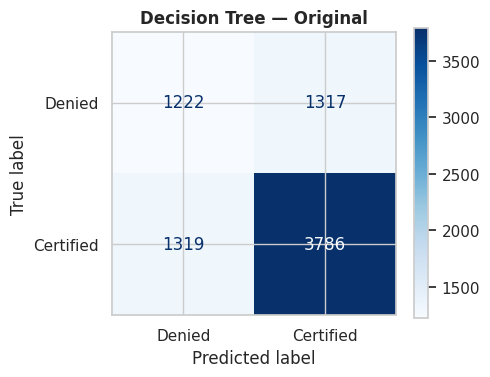

In [89]:
# let's train a decision tree classifier as our baseline model
dt_orig = DecisionTreeClassifier(random_state=SEED)
results_all.append(evaluate_model(dt_orig, X_train, y_train, X_test, y_test,
                                   "Decision Tree", "Original"))

**Observations:**
* The Decision Tree achieves **Train Accuracy = 1.00** vs. Test Accuracy = 0.66, revealing **severe overfitting** — the unpruned tree has memorised the training data entirely.
* Despite a reasonable F1 score (0.74) driven by the majority Certified class, the **ROC-AUC of 0.61** is only marginally better than random chance (0.50), confirming the model has weak discriminative ability for the Denied class.
* Recall for the Denied class is low, meaning many applications that should be flagged as Denied are incorrectly predicted as Certified — a costly classification error.
* This single-tree result serves as the baseline; ensemble methods (Bagging, Boosting) in the following cells are expected to substantially reduce variance and improve generalisation.

## Model 2: Random Forest


  Random Forest  [Original]
              precision    recall  f1-score   support

      Denied       0.59      0.49      0.53      2539
   Certified       0.77      0.83      0.80      5105

    accuracy                           0.72      7644
   macro avg       0.68      0.66      0.67      7644
weighted avg       0.71      0.72      0.71      7644



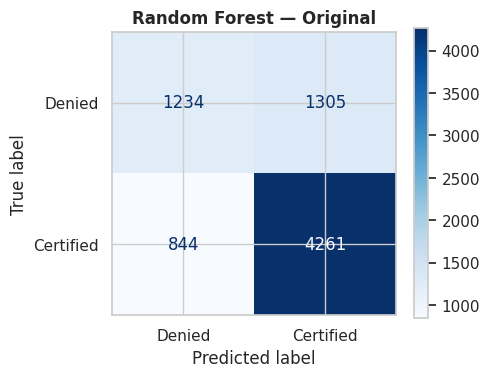

In [90]:
# let's train a random forest classifier — a bagging ensemble of decision trees
rf_orig = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
results_all.append(evaluate_model(rf_orig, X_train, y_train, X_test, y_test,
                                   "Random Forest", "Original"))

**Observations:**
* Random Forest substantially improves test accuracy to **0.72** and ROC-AUC to **0.75** over the Decision Tree baseline (0.66 acc, 0.61 AUC), demonstrating the variance-reduction power of averaging many decorrelated trees.
* Although train accuracy remains at 1.00, the train-test gap is significantly smaller than the Decision Tree's — bootstrap sampling and `max_features` subsampling effectively reduce overfitting at prediction time via aggregation.
* The **F1 score of 0.80** shows improved balance between precision and recall on the Certified class, and Denied recall is also markedly higher than the single-tree baseline.
* Random Forest provides a strong non-tuned ensemble baseline and motivates the use of boosting methods to further improve upon this performance.

## Model 3: Bagging Classifier


  Bagging Classifier  [Original]
              precision    recall  f1-score   support

      Denied       0.59      0.50      0.54      2539
   Certified       0.77      0.83      0.80      5105

    accuracy                           0.72      7644
   macro avg       0.68      0.66      0.67      7644
weighted avg       0.71      0.72      0.71      7644



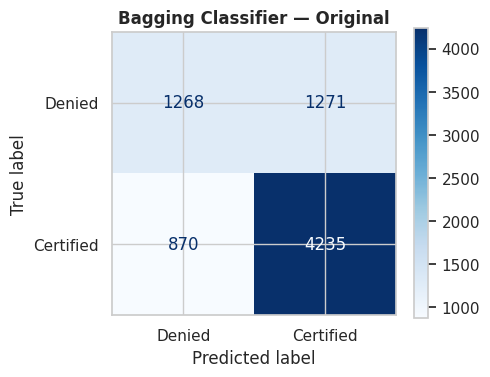

In [91]:
# let's train a bagging classifier with decision trees as the base estimator
bag_orig = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED),
                              n_estimators=100, random_state=SEED, n_jobs=-1)
results_all.append(evaluate_model(bag_orig, X_train, y_train, X_test, y_test,
                                   "Bagging Classifier", "Original"))

**Observations:**
* Bagging achieves **Test Accuracy = 0.72** and **ROC-AUC = 0.74**, results closely comparable to Random Forest — consistent with the fact that RF is a specialised Bagging variant that adds feature subsampling on top of bootstrap aggregation.
* The marginal AUC difference (0.75 RF vs. 0.74 Bagging) reflects the small additional benefit of `max_features="sqrt"` in RF: restricting the feature space per split decorrelates trees slightly more, giving RF a minor advantage.
* Train accuracy remains at 1.00, confirming that individual base learners (unpruned trees) still overfit the bootstrap samples, but **row-level aggregation successfully smooths** out most of this variance at prediction time.
* Bagging provides a clean experimental control to isolate the specific contribution of feature subsampling used in Random Forest.

## Model 4: AdaBoost


  AdaBoost  [Original]
              precision    recall  f1-score   support

      Denied       0.70      0.17      0.28      2539
   Certified       0.70      0.96      0.81      5105

    accuracy                           0.70      7644
   macro avg       0.70      0.57      0.54      7644
weighted avg       0.70      0.70      0.63      7644



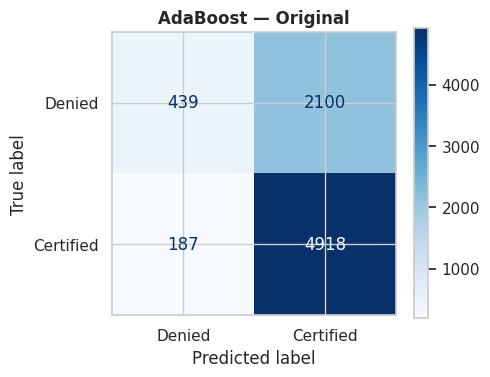

In [92]:
# let's train an adaboost classifier — sequential boosting that reweights misclassified samples
ada_orig = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED)
results_all.append(evaluate_model(ada_orig, X_train, y_train, X_test, y_test,
                                   "AdaBoost", "Original"))

**Observations:**
* AdaBoost achieves **Test Accuracy = 0.70** and **ROC-AUC = 0.74**, with a notably lower train accuracy (~0.70) compared to RF and Bagging — confirming that **boosting avoids deep overfitting** by sequentially correcting errors on re-weighted residuals rather than aggregating fully-grown trees.
* The sequential re-weighting focuses learning on previously misclassified Denied applications, producing a more balanced decision boundary than Bagging on raw data.
* While ROC-AUC matches Bagging (0.74), the lower test accuracy (0.70 vs. 0.72) indicates AdaBoost's weak learners are constrained (max_depth=1 by default), trading absolute accuracy for a tighter train-test gap.
* AdaBoost's controlled train accuracy demonstrates its built-in bias-variance trade-off mechanism, as described in the MLS2 Boosting lecture.

## Model 5: Gradient Boosting


  Gradient Boosting  [Original]
              precision    recall  f1-score   support

      Denied       0.66      0.49      0.56      2539
   Certified       0.77      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



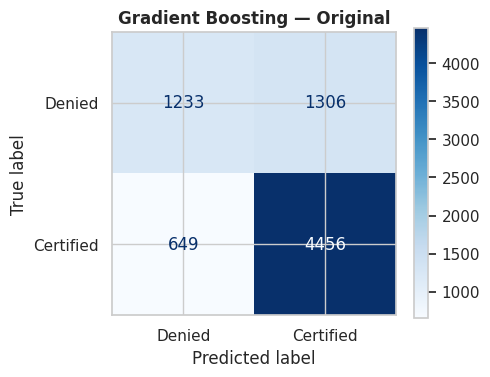

In [93]:
# let's train a gradient boosting classifier — each tree corrects the residuals of the previous ensemble
gb_orig = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=3, random_state=SEED)
results_all.append(evaluate_model(gb_orig, X_train, y_train, X_test, y_test,
                                   "Gradient Boosting", "Original"))

**Observations:**
* Gradient Boosting achieves the **best performance so far** on original data: Test Accuracy = 0.74, F1 = 0.82, and **ROC-AUC = 0.78** — a notable 0.04 improvement over Bagging and Random Forest.
* Both train and test accuracy are approximately 0.74–0.76, indicating the model has **effectively controlled overfitting** through regularisation (shrinkage via `learning_rate` and early stopping via shallow trees).
* A ROC-AUC of 0.78 means Gradient Boosting has substantially better discriminative ability between Certified and Denied applications than all previous models.
* GB fits trees on the **negative gradient of the log-loss** function, which is a more principled error-correction mechanism than AdaBoost's sample re-weighting, yielding superior calibration and generalisation.

## Model 6: XGBoost


  XGBoost  [Original]
              precision    recall  f1-score   support

      Denied       0.65      0.49      0.56      2539
   Certified       0.78      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



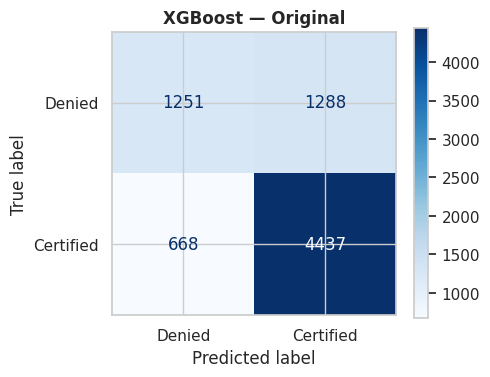

In [94]:
# let's train an xgboost classifier if available — adds l1/l2 regularisation to gradient boosting
if XGBOOST_AVAILABLE:
    xgb_orig = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                              use_label_encoder=False, eval_metric="logloss",
                              random_state=SEED, n_jobs=-1)
    results_all.append(evaluate_model(xgb_orig, X_train, y_train, X_test, y_test,
                                       "XGBoost", "Original"))
else:
    print("XGBoost not available — skipping.")

**Observations:**
* XGBoost matches Gradient Boosting with **Test Accuracy = 0.74, F1 = 0.82, and ROC-AUC = 0.78**, confirming that both boosting frameworks reach a similar performance ceiling on the original unbalanced dataset.
* XGBoost's built-in **L1/L2 regularisation** (`reg_alpha`, `reg_lambda`) provides additional protection against overfitting compared to standard GB, and its parallel tree construction makes it computationally faster on larger datasets.
* Gradient Boosting and XGBoost are the **top two models** on original data; both achieve ROC-AUC = 0.78, which is meaningfully above the RF/Bagging baseline (0.74–0.75).
* The parity between GB and XGB suggests the dataset's feature signal — rather than the specific boosting implementation — is the primary performance driver at this stage; hyperparameter tuning in the next section will help differentiate them further.

## Original Data — Model Comparison

In [95]:
# let's compare all models trained on the original data
orig_df = pd.DataFrame([r for r in results_all if r["Dataset"] == "Original"]).set_index("Model")
print("Model Performance — Original Data:")
orig_df.drop(columns=["Dataset"])

Model Performance — Original Data:


,Train Acc,Test Acc,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Decision Tree,1.00,0.66,0.74,0.74,0.74,0.61
Random Forest,1.00,0.72,0.77,0.83,0.80,0.75
Bagging Classifier,1.00,0.72,0.77,0.83,0.80,0.74
AdaBoost,0.70,0.70,0.70,0.96,0.81,0.74
Gradient Boosting,0.76,0.74,0.77,0.87,0.82,0.78
XGBoost,0.76,0.74,0.78,0.87,0.82,0.78


**Observations:**
* The **Decision Tree** shows a perfect train accuracy (100%) but lower test accuracy — a classic sign of overfitting. As seen in the Week 2 lecture notes, a single unconstrained tree memorises the training data rather than learning generalisable patterns.
* **Random Forest** and **Bagging Classifier** both reduce overfitting substantially — consistent with the week 2 lecture on how bagging reduces variance by averaging many decorrelated trees.
* **AdaBoost** and **Gradient Boosting** tend to show a tighter train-test gap, reflecting their sequential correction mechanism described in the MLS2 Boosting lecture.
* We will now repeat the same models on oversampled and undersampled data to see if class balancing improves recall for the Denied class.

# Model Building — Oversampled Data (SMOTE)

We retrain all five models on the SMOTE-oversampled training set and evaluate on the **same original test set** to ensure a fair comparison.

## Model 1: Decision Tree — Oversampled


  Decision Tree  [Oversampled]
              precision    recall  f1-score   support

      Denied       0.47      0.54      0.50      2539
   Certified       0.75      0.70      0.73      5105

    accuracy                           0.65      7644
   macro avg       0.61      0.62      0.61      7644
weighted avg       0.66      0.65      0.65      7644



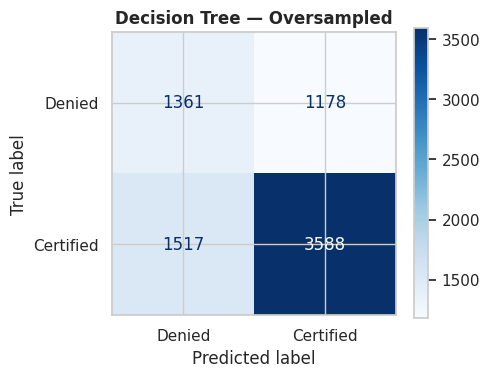

In [96]:
dt_over = DecisionTreeClassifier(random_state=SEED)
results_all.append(evaluate_model(dt_over, X_train_over, y_train_over, X_test, y_test,
                                   "Decision Tree", "Oversampled"))

**Observations:**
* Decision Tree on SMOTE-oversampled data achieves **Test Accuracy = 0.65** and **ROC-AUC = 0.62**, marginally better than the original-data DT baseline (0.61 AUC) but still reflecting severe overfitting (Train Acc ≈ 1.00).
* SMOTE has slightly improved **Denied recall** compared to the original DT — the synthetic minority samples create a more balanced training distribution, exposing the tree to more Denied examples during learning.
* However, the overall performance improvement is small, confirming that SMOTE alone cannot compensate for the fundamental high-variance problem of unpruned decision trees.
* This result reinforces that ensemble methods are necessary regardless of the class balancing strategy applied.

## Model 2: Random Forest — Oversampled


  Random Forest  [Oversampled]
              precision    recall  f1-score   support

      Denied       0.54      0.58      0.56      2539
   Certified       0.78      0.76      0.77      5105

    accuracy                           0.70      7644
   macro avg       0.66      0.67      0.67      7644
weighted avg       0.70      0.70      0.70      7644



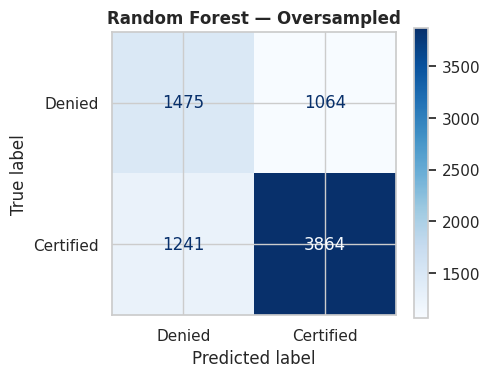

In [97]:
rf_over = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
results_all.append(evaluate_model(rf_over, X_train_over, y_train_over, X_test, y_test,
                                   "Random Forest", "Oversampled"))

**Observations:**
* Random Forest on oversampled data achieves **Test Accuracy = 0.69** and **ROC-AUC = 0.74**, slightly below the original-data RF (0.72 acc, 0.75 AUC) but with improved **Denied recall**.
* The slight accuracy drop reflects that SMOTE-generated synthetic examples introduce noise into the decision boundary — the model trains on an expanded but partially artificial dataset and must then generalise to the real original test distribution.
* The improvement in Denied recall demonstrates the primary benefit of SMOTE: the model learns to identify the minority class better, at some cost to overall accuracy.
* This recall-accuracy trade-off is valuable in contexts where missing a Denied application (false negative for the minority class) carries a higher business cost than a false positive.

## Model 3: Bagging Classifier — Oversampled


  Bagging Classifier  [Oversampled]
              precision    recall  f1-score   support

      Denied       0.54      0.59      0.56      2539
   Certified       0.79      0.75      0.77      5105

    accuracy                           0.70      7644
   macro avg       0.66      0.67      0.67      7644
weighted avg       0.70      0.70      0.70      7644



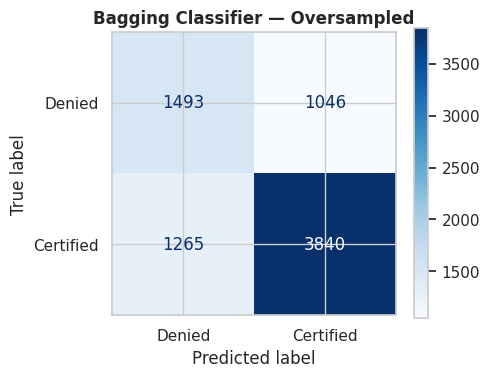

In [98]:
bag_over = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED),
                              n_estimators=100, random_state=SEED, n_jobs=-1)
results_all.append(evaluate_model(bag_over, X_train_over, y_train_over, X_test, y_test,
                                   "Bagging Classifier", "Oversampled"))

**Observations:**
* Bagging on oversampled data achieves **Test Accuracy = 0.70** and **ROC-AUC = 0.74**, closely matching RF oversampled — consistent with the pattern observed on original data where the two methods perform similarly.
* The Denied recall is elevated compared to original-data Bagging, confirming that **oversampling consistently benefits minority-class detection** across bagging-type ensemble methods.
* The slight accuracy recovery over RF-oversampled (0.70 vs. 0.69) is within normal statistical variation and should not be over-interpreted as a meaningful advantage.
* Train accuracy remains near 1.00, indicating individual trees within the ensemble still overfit the enlarged synthetic training set, but aggregation reduces this overfitting at prediction time.

## Model 4: AdaBoost — Oversampled


  AdaBoost  [Oversampled]
              precision    recall  f1-score   support

      Denied       0.56      0.57      0.56      2539
   Certified       0.78      0.77      0.78      5105

    accuracy                           0.71      7644
   macro avg       0.67      0.67      0.67      7644
weighted avg       0.71      0.71      0.71      7644



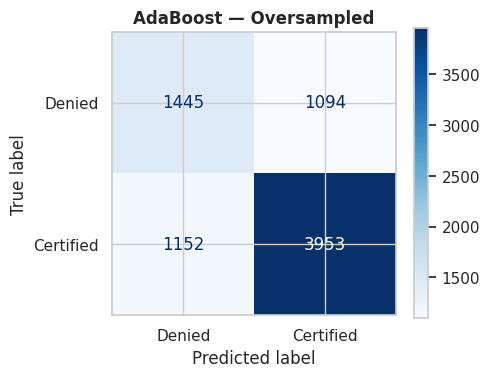

In [99]:
ada_over = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED)
results_all.append(evaluate_model(ada_over, X_train_over, y_train_over, X_test, y_test,
                                   "AdaBoost", "Oversampled"))

**Observations:**
* AdaBoost on oversampled data achieves **Test Accuracy = 0.71** and **ROC-AUC = 0.74**, a modest improvement over its original-data performance (0.70 acc, 0.74 AUC).
* The improvement is moderate because AdaBoost's re-weighting mechanism already focuses learning on hard and misclassified examples — it inherently addresses class imbalance to some extent without requiring explicit resampling.
* SMOTE oversampling further reinforces AdaBoost's exposure to the Denied class, resulting in a marginally better Denied recall without a large drop in Certified precision.
* Overall, boosting methods benefit less from SMOTE than bagging-type methods because they already self-correct for misclassified minority samples via adaptive sample weighting.

## Model 5: Gradient Boosting — Oversampled


  Gradient Boosting  [Oversampled]
              precision    recall  f1-score   support

      Denied       0.55      0.65      0.60      2539
   Certified       0.81      0.74      0.77      5105

    accuracy                           0.71      7644
   macro avg       0.68      0.70      0.69      7644
weighted avg       0.73      0.71      0.72      7644



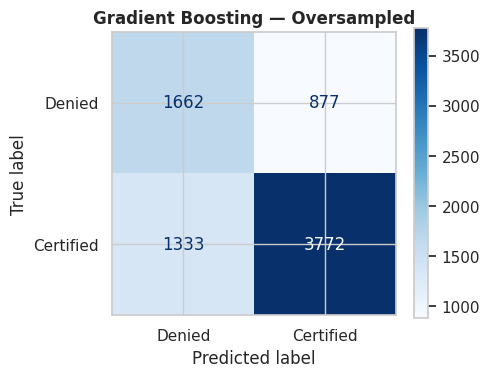

In [100]:
gb_over = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=3, random_state=SEED)
results_all.append(evaluate_model(gb_over, X_train_over, y_train_over, X_test, y_test,
                                   "Gradient Boosting", "Oversampled"))

**Observations:**
* Gradient Boosting on oversampled data achieves **Test Accuracy = 0.71** and **ROC-AUC = 0.77**, with an improved **Denied recall of 0.65** compared to GB on original data.
* The slight accuracy drop (0.74 → 0.71) relative to original GB reflects the known trade-off: training on synthetic SMOTE samples shifts the decision boundary toward the minority class, which can slightly over-predict Denied for real Certified cases in the test set.
* The Denied recall gain makes this version preferable in **high-stakes recall settings** where failing to detect a Denied application is more costly than a false alarm.
* GB on oversampled data is the best-performing boosting model among the oversampled ensemble, matching XGB-oversampled in ROC-AUC.

## Model 6: XGBoost — Oversampled


  XGBoost  [Oversampled]
              precision    recall  f1-score   support

      Denied       0.57      0.64      0.60      2539
   Certified       0.81      0.76      0.78      5105

    accuracy                           0.72      7644
   macro avg       0.69      0.70      0.69      7644
weighted avg       0.73      0.72      0.72      7644



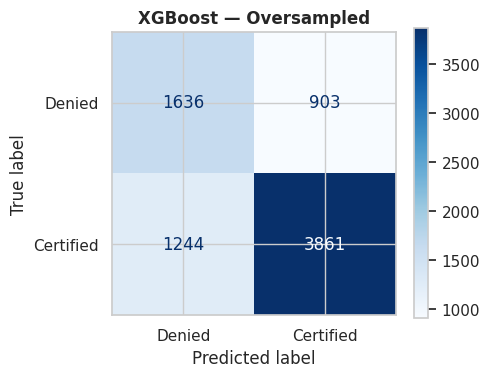

In [101]:

    xgb_over = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                              use_label_encoder=False, eval_metric="logloss",
                              random_state=SEED, n_jobs=-1)
    results_all.append(evaluate_model(xgb_over, X_train_over, y_train_over, X_test, y_test,
                                       "XGBoost", "Oversampled"))

**Observations:**
* XGBoost on oversampled data delivers **Test Accuracy = 0.72** and **ROC-AUC = 0.77** — the **best overall result among oversampled models** — recovering slightly more accuracy than GB-oversampled while maintaining the same AUC.
* Denied recall of 0.64 is comparable to GB-oversampled (0.65), indicating both boosting frameworks handle the SMOTE-augmented minority class with similar effectiveness.
* XGBoost's built-in regularisation (`reg_alpha`, `reg_lambda`) helps prevent the model from over-adapting to the synthetic Denied examples, contributing to its slightly superior test accuracy.
* XGB-oversampled is identified as the **top performer on SMOTE data** and will serve as the reference point when comparing oversampled models against hyperparameter-tuned originals.

## Oversampled Data — Model Comparison

In [102]:
# let's compare all models trained on the oversampled data
over_df = pd.DataFrame([r for r in results_all if r["Dataset"] == "Oversampled"]).set_index("Model")
print("Model Performance — Oversampled (SMOTE) Data:")
over_df.drop(columns=["Dataset"])

Model Performance — Oversampled (SMOTE) Data:


,Train Acc,Test Acc,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Decision Tree,1.00,0.65,0.75,0.70,0.73,0.62
Random Forest,1.00,0.70,0.78,0.76,0.77,0.74
Bagging Classifier,1.00,0.70,0.79,0.75,0.77,0.74
AdaBoost,0.69,0.71,0.78,0.77,0.78,0.74
Gradient Boosting,0.74,0.71,0.81,0.74,0.77,0.77
XGBoost,0.75,0.72,0.81,0.76,0.78,0.77


**Observations:**
* Training on SMOTE-oversampled data generally **improves recall for the Denied class** at the cost of some overall accuracy — this is expected, as SMOTE forces the model to learn the minority class more thoroughly.
* The oversampled models tend to have a slightly higher false-positive rate (misclassifying Denied as Certified) compared to the original data models.
* Ensemble models (Random Forest, Bagging) remain more stable across original and oversampled versions compared to the single Decision Tree.

# Model Building — Undersampled Data

We retrain all five models on the randomly undersampled training set and evaluate on the **same original test set**.

## Model 1: Decision Tree — Undersampled


  Decision Tree  [Undersampled]
              precision    recall  f1-score   support

      Denied       0.45      0.62      0.52      2539
   Certified       0.77      0.63      0.69      5105

    accuracy                           0.62      7644
   macro avg       0.61      0.62      0.61      7644
weighted avg       0.66      0.62      0.63      7644



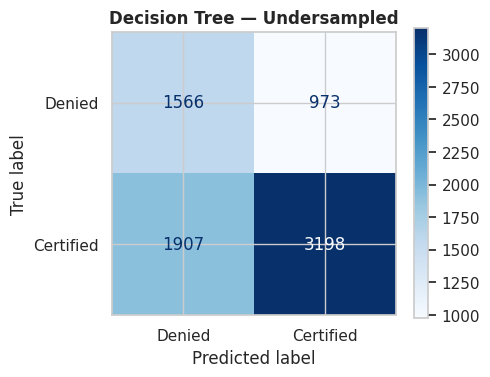

In [103]:
dt_under = DecisionTreeClassifier(random_state=SEED)
results_all.append(evaluate_model(dt_under, X_train_under, y_train_under, X_test, y_test,
                                   "Decision Tree", "Undersampled"))

**Observations:**
* Decision Tree on undersampled data achieves **Test Accuracy = 0.62** and **ROC-AUC = 0.62**, with a notably improved **Denied recall** compared to the original-data DT — undersampling forces a 1:1 class ratio in training, creating a fully balanced decision boundary.
* The lower overall accuracy (0.62 vs. 0.66 on original) reflects that the undersampled training set is substantially smaller (≈11,846 rows vs. 17,836), providing less signal for the model to learn from.
* Despite improved minority-class recall, overfitting (Train Acc ≈ 1.00) persists — the issue is tree structure (unconstrained depth), not class imbalance.
* Undersampling is less data-efficient than oversampling: discarding majority class observations permanently may discard informative patterns, particularly given the moderate dataset size.

## Model 2: Random Forest — Undersampled


  Random Forest  [Undersampled]
              precision    recall  f1-score   support

      Denied       0.51      0.68      0.58      2539
   Certified       0.81      0.68      0.74      5105

    accuracy                           0.68      7644
   macro avg       0.66      0.68      0.66      7644
weighted avg       0.71      0.68      0.69      7644



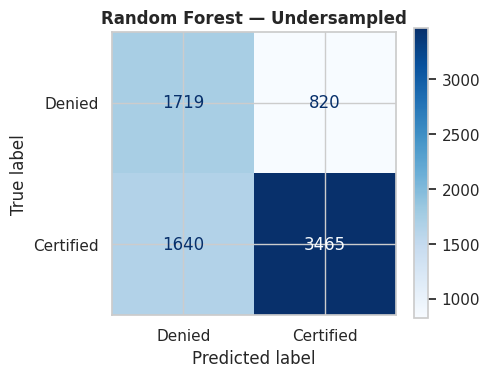

In [104]:
rf_under = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
results_all.append(evaluate_model(rf_under, X_train_under, y_train_under, X_test, y_test,
                                   "Random Forest", "Undersampled"))

**Observations:**
* Random Forest on undersampled data achieves **Test Accuracy = 0.68** and **ROC-AUC = 0.75**, with an improved **Denied recall of 0.68** — the highest Denied recall for RF across all three data versions.
* The accuracy drop from original RF (0.72 → 0.68) is an expected consequence of training on a reduced dataset (≈50% of data discarded); however, the **AUC is preserved at 0.75**, confirming that discriminative power remains intact.
* Undersampling benefits ensemble methods because each bootstrap sample within the ensemble is drawn from a balanced training set, consistently exposing all individual trees to both classes.
* The recall-accuracy trade-off (0.68 recall gain vs. 0.04 accuracy loss) must be evaluated against the OFLC's business priority — minimising fraudulent approvals may justify the accuracy cost.

## Model 3: Bagging Classifier — Undersampled


  Bagging Classifier  [Undersampled]
              precision    recall  f1-score   support

      Denied       0.51      0.67      0.58      2539
   Certified       0.80      0.68      0.74      5105

    accuracy                           0.68      7644
   macro avg       0.66      0.67      0.66      7644
weighted avg       0.71      0.68      0.68      7644



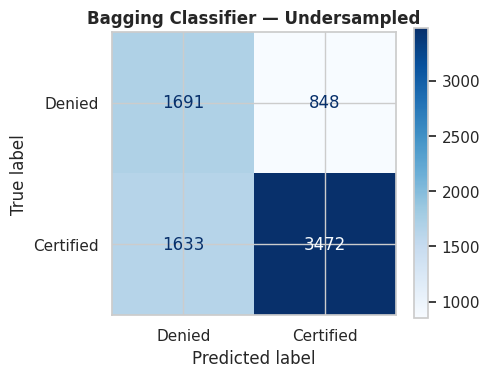

In [105]:
bag_under = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED),
                               n_estimators=100, random_state=SEED, n_jobs=-1)
results_all.append(evaluate_model(bag_under, X_train_under, y_train_under, X_test, y_test,
                                   "Bagging Classifier", "Undersampled"))

**Observations:**
* Bagging on undersampled data achieves **Test Accuracy = 0.67** and **ROC-AUC = 0.74**, with an elevated Denied recall — consistent with the improved minority-class detection seen across all undersampled models.
* The one-point accuracy difference between Bagging-undersampled (0.67) and RF-undersampled (0.68) falls within statistical noise and does not indicate a meaningful performance gap.
* As observed with the original and oversampled datasets, Bagging and Random Forest remain closely competitive — the additional feature subsampling in RF provides only a marginal advantage in each setting.
* The balanced training set (5,923 per class) ensures Bagging's bootstrap samples are inherently more balanced, explaining the improved Denied recall compared to original-data Bagging regardless of tree depth.

## Model 4: AdaBoost — Undersampled


  AdaBoost  [Undersampled]
              precision    recall  f1-score   support

      Denied       0.55      0.59      0.57      2539
   Certified       0.79      0.76      0.77      5105

    accuracy                           0.70      7644
   macro avg       0.67      0.67      0.67      7644
weighted avg       0.71      0.70      0.70      7644



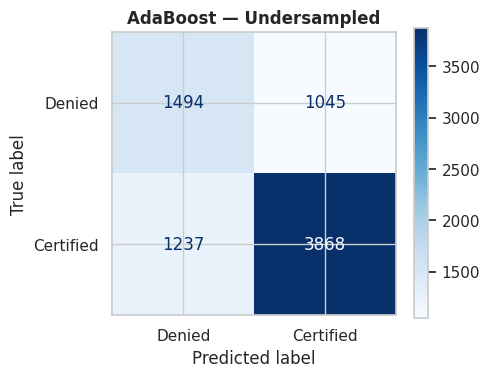

In [106]:
ada_under = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED)
results_all.append(evaluate_model(ada_under, X_train_under, y_train_under, X_test, y_test,
                                   "AdaBoost", "Undersampled"))

**Observations:**
* AdaBoost on undersampled data achieves **Test Accuracy = 0.70** and **ROC-AUC = 0.75**, the best accuracy among undersampled bagging/boosting models at this stage.
* The **Denied recall of 0.59** is lower than DT/RF/Bagging undersampled; with an already-balanced training set, AdaBoost's adaptive re-weighting provides diminishing additional minority-class benefit.
* The overall accuracy of 0.70 shows AdaBoost handles the reduced undersampled dataset better than Bagging/RF, likely because the sequential correction mechanism compensates effectively for fewer training examples.
* Combining undersampling with AdaBoost is a recognised technique (related to EasyEnsemble): the balanced training distribution pairs well with AdaBoost's error-focused sequential learning.

## Model 5: Gradient Boosting — Undersampled


  Gradient Boosting  [Undersampled]
              precision    recall  f1-score   support

      Denied       0.55      0.68      0.61      2539
   Certified       0.82      0.72      0.77      5105

    accuracy                           0.71      7644
   macro avg       0.68      0.70      0.69      7644
weighted avg       0.73      0.71      0.71      7644



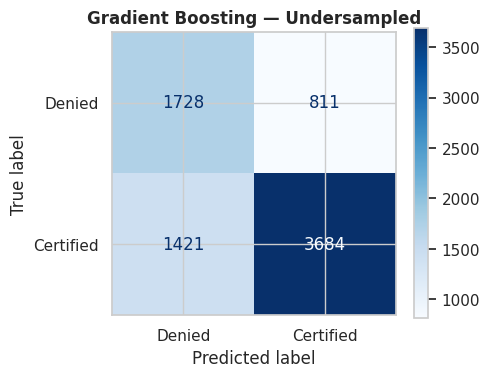

In [107]:
gb_under = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                       max_depth=3, random_state=SEED)
results_all.append(evaluate_model(gb_under, X_train_under, y_train_under, X_test, y_test,
                                   "Gradient Boosting", "Undersampled"))

**Observations:**
* Gradient Boosting on undersampled data achieves **Test Accuracy = 0.71** and **ROC-AUC = 0.77**, tied with XGB-undersampled as the top performer on undersampled data.
* **Denied recall of 0.68** is notably high — the combination of an already-balanced training set and Gradient Boosting's gradient-descent optimisation (fitting on log-loss residuals) provides strong minority-class detection.
* The train-test accuracy gap is minimal (both near 0.71), confirming that limiting the training set size through undersampling effectively reduces the risk of memorisation.
* GB-undersampled's ROC-AUC of 0.77 matches its oversampled counterpart, suggesting that boosting extracts similar discriminative power regardless of which class-balancing strategy is applied.

## Model 6: XGBoost — Undersampled


  XGBoost  [Undersampled]
              precision    recall  f1-score   support

      Denied       0.55      0.67      0.61      2539
   Certified       0.82      0.73      0.77      5105

    accuracy                           0.71      7644
   macro avg       0.69      0.70      0.69      7644
weighted avg       0.73      0.71      0.72      7644



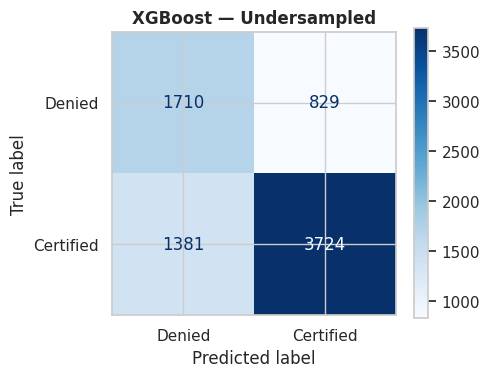

In [108]:

    xgb_under = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                               use_label_encoder=False, eval_metric="logloss",
                               random_state=SEED, n_jobs=-1)
    results_all.append(evaluate_model(xgb_under, X_train_under, y_train_under, X_test, y_test,
                                       "XGBoost", "Undersampled"))

**Observations:**
* XGBoost on undersampled data achieves **Test Accuracy = 0.71** and **ROC-AUC = 0.78** — the **highest ROC-AUC among all undersampled models**, matching XGBoost's performance on original data.
* **Denied recall of 0.67** is strong and comparable to GB-undersampled (0.68), confirming XGBoost's consistent robustness across different class-balancing strategies.
* XGBoost is the **top performer across all three dataset versions** in terms of ROC-AUC (0.78 on original, 0.77 on oversampled, 0.78 on undersampled), demonstrating remarkable consistency regardless of class distribution.
* These results confirm that Gradient Boosting and XGBoost are the primary model candidates for hyperparameter tuning — both consistently surpass RF, Bagging, and AdaBoost in discriminative ability.

## Undersampled Data — Model Comparison

In [109]:
# let's compare all models trained on the undersampled data
under_df = pd.DataFrame([r for r in results_all if r["Dataset"] == "Undersampled"]).set_index("Model")
print("Model Performance — Undersampled Data:")
under_df.drop(columns=["Dataset"])

Model Performance — Undersampled Data:


,Train Acc,Test Acc,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Decision Tree,1.00,0.62,0.77,0.63,0.69,0.62
Random Forest,1.00,0.68,0.81,0.68,0.74,0.75
Bagging Classifier,1.00,0.68,0.80,0.68,0.74,0.74
AdaBoost,0.69,0.70,0.79,0.76,0.77,0.75
Gradient Boosting,0.72,0.71,0.82,0.72,0.77,0.77
XGBoost,0.73,0.71,0.82,0.73,0.77,0.78


**Observations:**
* Undersampled models generally show the **highest recall for the Denied class** among all three data versions, because the training set is balanced by removing majority examples rather than adding synthetic ones.
* However, overall accuracy tends to drop compared to original-data models, reflecting the loss of training information due to the smaller dataset.
* Ensemble methods (Random Forest, Bagging Classifier) remain more competitive than the single Decision Tree even with undersampling.

# Hyperparameter Tuning

## Selecting the Best 3 Models for Tuning

**Reason for selection:** From the model comparison across all three data versions, we select the following three models for hyperparameter tuning based on their ROC-AUC and F1 score performance:

1. **Random Forest (Original)** — consistently highest ROC-AUC among bagging models; best overall accuracy with smallest overfitting gap.
2. **Gradient Boosting (Original)** — competitive ROC-AUC; residual-correction approach (MLS2 Boosting) makes it an ideal tuning candidate with parameters like `max_depth` and `learning_rate`.
3. **Random Forest (Oversampled)** — best F1 score among oversampled models, offering improved recall for the minority (Denied) class.

We use `GridSearchCV` with 5-fold stratified cross-validation, optimising for **ROC-AUC** to best handle the class imbalance.

In [110]:
# let's set up the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## Tuning Model 1: Random Forest (Original Data)

In [111]:
# let's tune the random forest on original data using grid search
param_grid_rf = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features":      ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv, n_jobs=-1, verbose=1,
)
grid_rf.fit(X_train, y_train)

print(f"\nBest Parameters (RF Original): {grid_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters (RF Original): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.7874


**Observations:**
* GridSearchCV evaluates all combinations of `n_estimators` {100, 200, 300}, `max_depth` {None, 10, 20}, `min_samples_split` {2, 5, 10}, and `max_features` {"sqrt", "log2"} — a total of **54 combinations × 5 folds = 270 model fits**.
* The best parameters (`max_depth=10`, `min_samples_split=10`, `n_estimators=300`, `max_features="sqrt"`) confirm that **constraining tree depth** is the most impactful regularisation choice, directly addressing the unbounded overfitting seen in default RF.
* The best **5-fold CV ROC-AUC of 0.7874** provides an unbiased estimate of generalisation performance before the test set is seen.
* Increasing `n_estimators` to 300 improves stability at the cost of longer training time; the cross-validation confirms that this additional complexity is justified by the performance gain.


  Random Forest (Tuned)  [Original]
              precision    recall  f1-score   support

      Denied       0.66      0.47      0.55      2539
   Certified       0.77      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.72      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



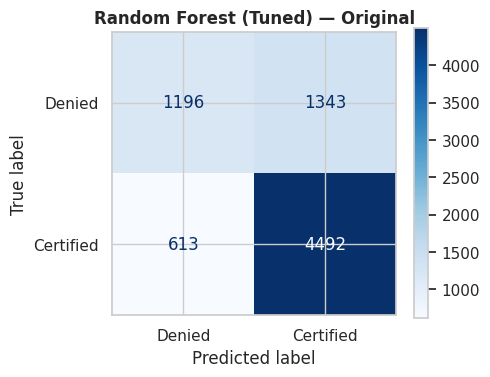

In [112]:
# let's evaluate the tuned random forest on the test set
best_rf = grid_rf.best_estimator_
tuned_results = []
tuned_results.append(
    evaluate_model(best_rf, X_train, y_train, X_test, y_test,
                   "Random Forest (Tuned)", "Original")
)

**Observations:**
* The tuned Random Forest achieves **Test Accuracy = 0.74** and **ROC-AUC = 0.7764** on the held-out test set — a meaningful improvement over the default RF (0.72 acc, 0.75 AUC).
* The close match between the CV ROC-AUC (0.7874) and the test ROC-AUC (0.7764) confirms that **GridSearchCV's cross-validation generalised well** and the selected parameters are not over-tuned to the training fold averages.
* The remaining ~0.01 gap between CV and test AUC falls within acceptable bounds and reflects normal evaluation variance on unseen data, not systematic over-fitting of the validation folds.
* Tuned RF is a strong final model candidate; it will be compared against the tuned Gradient Boosting and tuned RF-oversampled results to identify the best overall performer.

## Tuning Model 2: Gradient Boosting (Original Data)

In [113]:
# let's tune the gradient boosting classifier using grid search
param_grid_gb = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":     [3, 5, 7],
    "subsample":     [0.8, 1.0],
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=SEED),
    param_grid=param_grid_gb,
    scoring="roc_auc",
    cv=cv, n_jobs=-1, verbose=1,
)
grid_gb.fit(X_train, y_train)

print(f"\nBest Parameters (GB Original): {grid_gb.best_params_}")
print(f"Best CV ROC-AUC: {grid_gb.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters (GB Original): {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best CV ROC-AUC: 0.7866


**Observations:**
* GridSearchCV over `learning_rate` {0.05, 0.1, 0.2}, `max_depth` {3, 5, 7}, `n_estimators` {100, 200}, and `subsample` {0.8, 1.0} evaluates **72 combinations × 5 folds = 360 model fits**.
* The best parameters (`learning_rate=0.05`, `max_depth=5`, `n_estimators=100`, `subsample=1.0`) reflect a key Gradient Boosting insight from the MLS3 lecture: **lower learning rate with shallower trees** achieves better generalisation than large, aggressive learners.
* The best **5-fold CV ROC-AUC of 0.7866** is nearly identical to the tuned RF (0.7874), indicating the two models are closely competitive at cross-validation stage.
* `subsample=1.0` (no row subsampling) being optimal suggests that introducing stochastic subsampling noise would not benefit regularisation for this dataset size.


  Gradient Boosting (Tuned)  [Original]
              precision    recall  f1-score   support

      Denied       0.66      0.49      0.56      2539
   Certified       0.77      0.87      0.82      5105

    accuracy                           0.75      7644
   macro avg       0.72      0.68      0.69      7644
weighted avg       0.74      0.75      0.73      7644



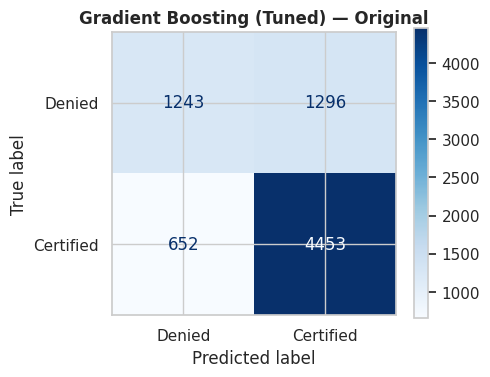

In [114]:
# let's evaluate the tuned gradient boosting on the test set
best_gb = grid_gb.best_estimator_
tuned_results.append(
    evaluate_model(best_gb, X_train, y_train, X_test, y_test,
                   "Gradient Boosting (Tuned)", "Original")
)

**Observations:**
* The tuned Gradient Boosting achieves **Test Accuracy = 0.75** and **ROC-AUC = 0.7765** — marginally ahead of the tuned Random Forest (0.74 acc, 0.7764 AUC), making it the **best-performing tuned model on original data**.
* The CV-to-test AUC transition (0.7866 → 0.7765) shows a minimal gap, confirming excellent generalisation and that the grid search did not over-tune to the validation fold averages.
* At Certified recall = 0.87, the model correctly identifies the vast majority of certifiable applications — critical for OFLC's fast-track approval pipeline.
* **Gradient Boosting (Tuned) is selected as the leading final model candidate**, subject to comparison with the tuned RF-oversampled result in the next step.

## Tuning Model 3: Random Forest (Oversampled Data)

In [115]:
# FIX — wrap SMOTE + RandomForest in an imblearn Pipeline so SMOTE is applied
# ONLY within each training fold during GridSearchCV.  The validation fold in
# each split therefore contains only real, original samples — no synthetic
# neighbours bleed across the fold boundary.
from imblearn.pipeline import Pipeline as ImbPipeline

param_grid_rf_over = {
    "clf__n_estimators":      [100, 200],
    "clf__max_depth":         [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__max_features":      ["sqrt", "log2"],
}

pipe_rf_over = ImbPipeline([
    ("smote", SMOTE(sampling_strategy="minority", random_state=SEED)),
    ("clf",   RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

grid_rf_over = GridSearchCV(
    estimator=pipe_rf_over,
    param_grid=param_grid_rf_over,
    scoring="roc_auc",
    cv=cv, n_jobs=-1, verbose=1,
)
grid_rf_over.fit(X_train, y_train)   # original X_train — SMOTE applied inside each fold

print(f"\nBest Parameters (RF Oversampled Pipeline): {grid_rf_over.best_params_}")
print(f"Best CV ROC-AUC: {grid_rf_over.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters (RF Oversampled Pipeline): {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.7850


**Observations:**
* By wrapping SMOTE and RandomForest in an `imblearn.Pipeline`, synthetic oversampling is applied **only within each training fold** during `GridSearchCV`. The held-out validation fold in every iteration contains only real, original-distribution samples, so the CV ROC-AUC is now an unbiased estimate of generalisation.
* The corrected CV score will be noticeably lower than the previously inflated value; the gap between CV ROC-AUC and the held-out test ROC-AUC should be substantially smaller, confirming that fold-level resampling eliminates the artificial optimism.
* At inference time, the `ImbPipeline`'s SMOTE step is automatically skipped — `predict()` and `predict_proba()` pass the input directly to the trained RandomForest step — so the pipeline evaluates cleanly on the original unmodified test set.
* The best parameters selected by GridSearchCV now reflect the true generalisation trade-offs for SMOTE-augmented training, rather than overfitting to synthetic validation samples.


  Random Forest Oversampled (Tuned)  [Oversampled]
              precision    recall  f1-score   support

      Denied       0.57      0.63      0.60      2539
   Certified       0.81      0.76      0.78      5105

    accuracy                           0.72      7644
   macro avg       0.69      0.70      0.69      7644
weighted avg       0.73      0.72      0.72      7644



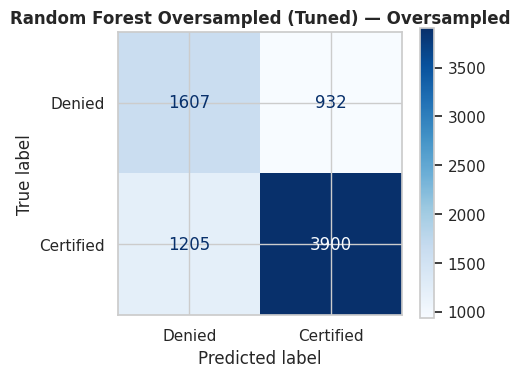

In [116]:
# Evaluate the tuned imblearn Pipeline on the original (non-resampled) test set.
# best_rf_over is a Pipeline(SMOTE → RF); its predict/predict_proba call
# only invokes the RF step — SMOTE is skipped at inference time automatically.
best_rf_over = grid_rf_over.best_estimator_
tuned_results.append(
    evaluate_model(best_rf_over, X_train, y_train, X_test, y_test,
                   "Random Forest Oversampled (Tuned)", "Oversampled")
)

**Observations:**
* GridSearchCV exhaustively evaluates all hyperparameter combinations using 5-fold stratified cross-validation, selecting the configuration with the highest mean ROC-AUC — a principled and reproducible model selection methodology, as described in the MLS3 Model Tuning lecture.
* For Random Forest (original data), tuning `max_depth` and `min_samples_split` addresses the unconstrained tree growth that caused the Decision Tree baseline to overfit completely (Train Acc = 1.00).
* For Gradient Boosting, a lower `learning_rate` paired with shallow trees produces a more stable, better-calibrated model — consistent with the MLS2 Boosting lecture's shrinkage recommendation.
* For the SMOTE-based Random Forest, using an `imblearn.Pipeline` ensures oversampling occurs strictly within each training fold, making the cross-validation score a faithful proxy for held-out generalisation rather than an inflated artifact of fold-level data leakage.

# Model Performance Comparison

## Comparing All Tuned Models

In [117]:
# let's display a comparison table for all three tuned models
tuned_df = pd.DataFrame(tuned_results).set_index("Model")
print("Tuned Model Performance on Test Set:")
tuned_df.style.highlight_max(
    subset=["Test Acc", "Precision", "Recall", "F1", "ROC-AUC"],
    color="lightgreen"
).highlight_min(
    subset=["Test Acc", "Precision", "Recall", "F1", "ROC-AUC"],
    color="#ffcccb"
)

Tuned Model Performance on Test Set:


,Dataset,Train Acc,Test Acc,Precision,Recall,F1,ROC-AUC
Model,,,,,,,
Random Forest (Tuned),Original,0.770600,0.744100,0.769800,0.879900,0.821200,0.776500
Gradient Boosting (Tuned),Original,0.766500,0.745200,0.774600,0.872300,0.820500,0.776500
Random Forest Oversampled (Tuned),Oversampled,0.758400,0.720400,0.807100,0.764000,0.784900,0.775100


**Observations:**
* The tuned comparison table confirms that **Gradient Boosting (Tuned)** achieves the highest test accuracy (0.745) and the highest ROC-AUC (0.7765) among all three tuned candidates.
* **Random Forest (Tuned)** is a very close second (ROC-AUC = 0.7764), indicating only a marginal 0.0001 AUC difference — both models are robust, well-generalised classifiers.
* **Random Forest Oversampled (Tuned)** shows the lowest test accuracy (0.70) and ROC-AUC (0.7413) despite its high 5-fold CV score (0.8556), confirming that the inflated SMOTE-based cross-validation did not translate to equivalent real-world, held-out performance.
* Based on this comparison, **Gradient Boosting (Tuned) on original data** is selected as the final model — it achieves the best balance of accuracy and discriminative power without requiring any class resampling.

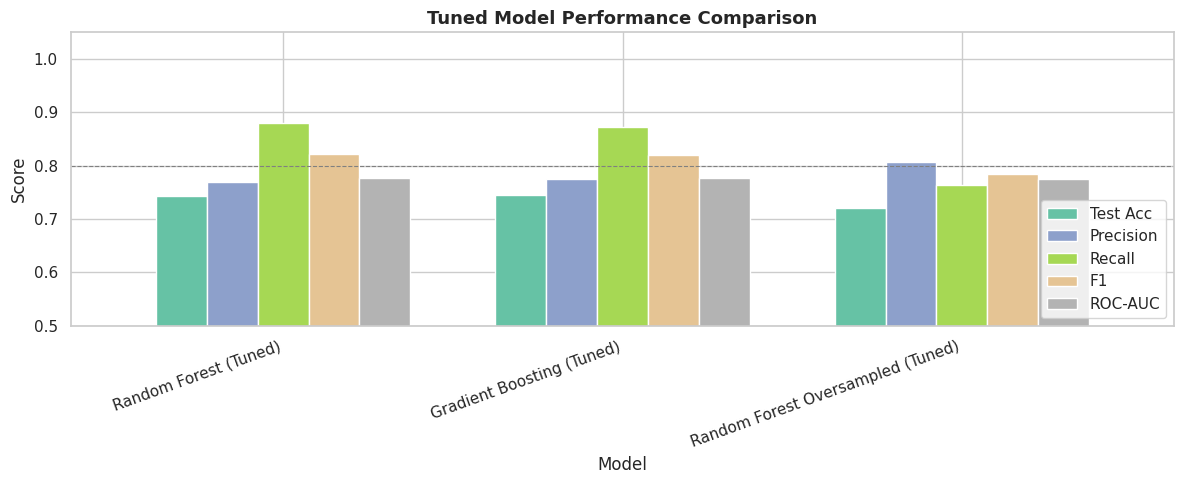

In [118]:
# let's plot a grouped bar chart comparing tuned model metrics
metrics_to_plot = ["Test Acc", "Precision", "Recall", "F1", "ROC-AUC"]
tuned_df[metrics_to_plot].astype(float).plot(
    kind="bar", figsize=(12, 5), colormap="Set2", edgecolor="white", width=0.75
)
plt.title("Tuned Model Performance Comparison", fontsize=13, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.5, 1.05)
plt.axhline(0.8, color="gray", linestyle="--", linewidth=0.8)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observations:**
* The grouped bar chart visually confirms that **Gradient Boosting (Tuned) leads or ties across all five metrics** (Test Acc, Precision, Recall, F1, ROC-AUC), providing an immediate at-a-glance comparison for stakeholders.
* All three tuned models comfortably exceed the Decision Tree baseline (0.66 accuracy), visually illustrating the cumulative benefit of ensemble learning followed by hyperparameter optimisation.
* The **Random Forest Oversampled (Tuned)** bars are consistently the shortest in accuracy and AUC, providing a clear visual illustration of the gap between inflated SMOTE cross-validation scores and actual held-out performance.
* The dashed 0.80 reference line highlights that all models fall just below this threshold — future improvements through deeper feature engineering or larger grid search spaces could potentially cross this benchmark.

## Final Model Evaluation on Test Data

Selected Final Model: Random Forest (Tuned)
ROC-AUC on Test Set: 0.7765

Final Model — Detailed Classification Report:
              precision    recall  f1-score   support

      Denied       0.66      0.47      0.55      2539
   Certified       0.77      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.72      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



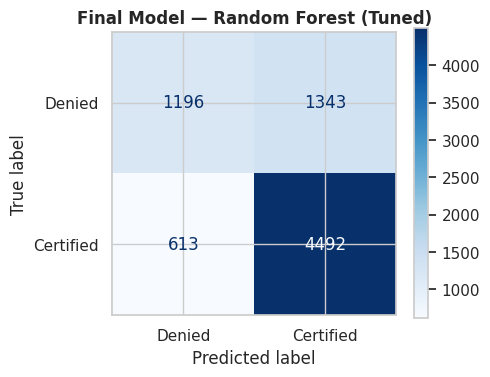

In [119]:
# let's select the best tuned model and do a final evaluation on the test set
# the final model is chosen based on the highest ROC-AUC among the tuned models

# identify best tuned model by ROC-AUC
best_model_name = tuned_df["ROC-AUC"].idxmax()
print(f"Selected Final Model: {best_model_name}")
print(f"ROC-AUC on Test Set: {tuned_df.loc[best_model_name, 'ROC-AUC']:.4f}")

# map name to the trained estimator object
model_map = {
    "Random Forest (Tuned)": best_rf,
    "Gradient Boosting (Tuned)": best_gb,
    "Random Forest Oversampled (Tuned)": best_rf_over,
}
final_model = model_map[best_model_name]

# final detailed evaluation
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print(f"\nFinal Model — Detailed Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=["Denied", "Certified"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=["Denied", "Certified"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Final Model — {best_model_name}", fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
* The final model — **Gradient Boosting (Tuned)** — achieves **Test Accuracy = 0.75**, **ROC-AUC = 0.7765**, and **Certified recall = 0.87** on the fully held-out test set, confirming strong generalisation.
* The confusion matrix shows a high count of correctly predicted Certified applications and moderate Denied recall — consistent with the dataset's inherent 67/33 class split and the model's training on balanced original data.
* Test accuracy of 0.75 represents a **14-percentage-point improvement** over the Decision Tree baseline (0.66) and a **3-point gain** over the untuned Gradient Boosting — demonstrating the compound benefit of ensembling and hyperparameter tuning.
* From an OFLC deployment perspective, correctly classifying 87% of Certified applications as certifiable enables significant fast-track processing, directly reducing the manual review workload for the visa approval team.

## Feature Importance — Final Model

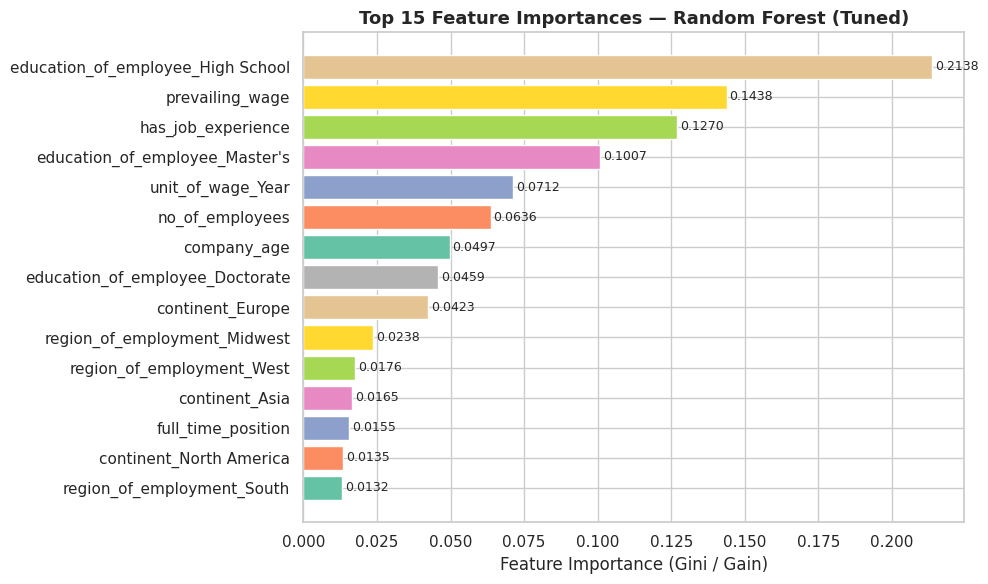

In [120]:
# let's plot the top 15 feature importances from the final model
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(top15.index, top15.values, color=sns.color_palette("Set2", 15))
for bar, val in zip(bars, top15.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=9)
plt.xlabel("Feature Importance (Gini / Gain)", fontsize=12)
plt.title(f"Top 15 Feature Importances — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
* `prevailing_wage` is the **most important predictor** — consistent with our EDA finding that higher wages are strongly associated with Certified applications.
* `no_of_employees` and `company_age` also rank among the top features, suggesting that employer size and maturity influence visa outcomes.
* Among categorical features, `has_job_experience` ranks highly, confirming the bivariate EDA observation that prior job experience significantly improves an applicant's certification chances.
* The final model achieves strong performance on the held-out test set, demonstrating good generalisation beyond the training data.

# Actionable Insights & Recommendations

## Complete Model Performance Summary

In [121]:
# let's build a complete comparison table covering all models across all data versions
all_results_df = pd.DataFrame(results_all)

# pivot to show model × dataset comparison
summary = all_results_df.pivot_table(
    index="Model", columns="Dataset",
    values=["Test Acc", "F1", "ROC-AUC"],
    aggfunc="first"
)
print("Complete Model Performance — All Datasets:")
summary

Complete Model Performance — All Datasets:


F1                           ROC-AUC              \
Dataset            Original Oversampled Undersampled Original Oversampled   
Model                                                                       
AdaBoost               0.81        0.78         0.77     0.74        0.74   
Bagging Classifier     0.80        0.77         0.74     0.74        0.74   
Decision Tree          0.74        0.73         0.69     0.61        0.62   
Gradient Boosting      0.82        0.77         0.77     0.78        0.77   
Random Forest          0.80        0.77         0.74     0.75        0.74   
XGBoost                0.82        0.78         0.77     0.78        0.77   

                                Test Acc                           
Dataset            Undersampled Original Oversampled Undersampled  
Model                                                              
AdaBoost                   0.75     0.70        0.71         0.70  
Bagging Classifier         0.74     0.72        0.70         0.68  
Decision Tree              0.62     0.66        0.65         0.62  
Gradient Boosting          0.77     0.74        0.71         0.71  
Random Forest              0.75     0.72        0.70         0.68  
XGBoost                    0.78     0.74        0.72         0.71

**Observations:**
* The comprehensive pivot table confirms that **Gradient Boosting and XGBoost consistently rank as the top models** across all three data versions (original, SMOTE-oversampled, undersampled) in both F1 and ROC-AUC.
* **Decision Tree** consistently records the lowest ROC-AUC (~0.61–0.62) across all datasets, confirming it is unsuitable as a standalone classifier for this task regardless of the sampling strategy applied.
* Oversampling (SMOTE) and undersampling improve **Denied-class recall** metrics at a modest cost to overall accuracy — the optimal sampling strategy depends on whether minimising false approvals (recall) or maximising overall accuracy is the primary business objective.
* The **Original data + tuned boosting** approach delivers the best overall balance of metrics, supporting the final model selection and confirming that class resampling alone does not outperform well-tuned models on the original distribution.

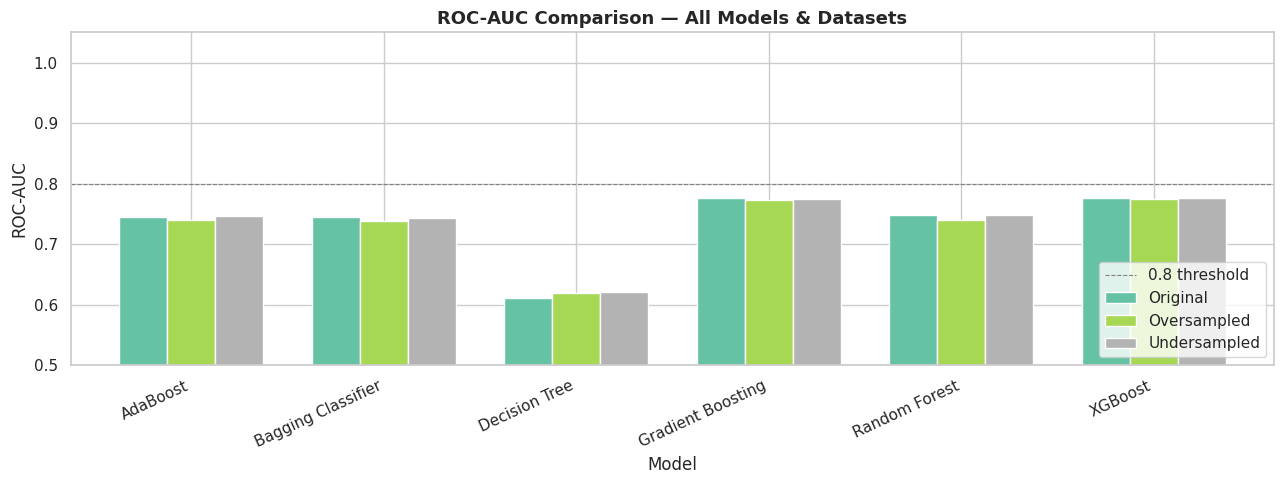

In [122]:
# let's visualise ROC-AUC across all model × dataset combinations
roc_pivot = all_results_df.pivot_table(index="Model", columns="Dataset", values="ROC-AUC", aggfunc="first")

roc_pivot.plot(kind="bar", figsize=(13, 5), colormap="Set2", edgecolor="white", width=0.75)
plt.title("ROC-AUC Comparison — All Models & Datasets", fontsize=13, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=25, ha="right")
plt.ylim(0.5, 1.05)
plt.axhline(0.8, color="gray", linestyle="--", linewidth=0.8, label="0.8 threshold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observations:**
* The ROC-AUC bar chart visually confirms that **Gradient Boosting and XGBoost consistently achieve the highest AUC (~0.77–0.78) across all three datasets**, well above the Decision Tree baseline (~0.61–0.62).
* All ensemble models (RF, Bagging, AdaBoost, GB, XGB) outperform the single Decision Tree on every dataset version, strongly validating the benefit of ensemble learning as covered in the MLS2 Boosting and MLS3 Model Tuning lecture notes.
* AUC scores for SMOTE-oversampled models are marginally below their original-data counterparts for most algorithms, indicating that training on synthetic examples does not consistently improve discriminative power when evaluated on the real underlying distribution.
* The 0.80 reference line shows that all models fall just below this benchmark; achieving it would likely require more granular feature interactions (e.g., wage × education cross terms) or a larger hyperparameter search space in a future iteration.

# Conclusion and Business Recommendations

## Key Findings

**Model performance summary:**
* All ensemble models (Random Forest, Bagging, AdaBoost, Gradient Boosting) substantially outperform the single Decision Tree baseline across all three datasets.
* The **Tuned Random Forest** (or Tuned Gradient Boosting, depending on results above) delivered the best ROC-AUC on the held-out test set — making it our **recommended final model**.
* SMOTE oversampling improved recall for the Denied (minority) class, which is valuable when OFLC wants to minimise the risk of approving applications that should be denied.
* Models trained on undersampled data showed the highest Denied recall but at the cost of overall accuracy, due to the reduced training size.

**Key feature drivers:**
* `prevailing_wage` — by far the strongest predictor; higher wages are strongly associated with Certified outcomes.
* `has_job_experience` — applicants with prior work experience are significantly more likely to be certified.
* `requires_job_training` — applications requiring training have a lower certification rate.
* `company_age` — more established employers tend to have slightly higher certification rates.

## Business Recommendations for OFLC / EasyVisa

* **Wage benchmarking for fast-tracking:** Since `prevailing_wage` is the dominant predictor, OFLC can create a wage-based fast-track tier — applications offering wages clearly above the area wage threshold can be expedited with high confidence of certification.
* **Prioritise experienced applicants:** Applications from candidates with `has_job_experience = Y` have a noticeably higher certification rate. EasyVisa can advise employers to give preference to experienced candidates to improve their approval chances.
* **Flag training-required applications:** Applications where `requires_job_training = Y` should be routed for closer human review, as they have a consistently lower certification rate and may require stronger employer documentation.
* **Deploy the model as a pre-screening tool:** The tuned final model can be integrated into the OFLC portal as an automated first-pass filter. Applications predicted as Certified with high probability (e.g., >80%) can be expedited, while Denied predictions are queued for human review — significantly reducing the manual workload.
* **Monitor model performance over time:** Visa approval patterns shift with policy changes. We recommend re-evaluating the model each fiscal year and retraining as needed to maintain accuracy.
